# Uncertainty Quantification via Log Probabilities
## MSc Project: Trustworthy SLMs for Ambient Clinical Scribing

This notebook reproduces all log-probability uncertainty analyses from `logprobs_analysis.py`
and adds **distribution-level box plots** across all 50 evaluation samples, addressing
the supervisor's observation that mean-only summaries hide per-sample variability.

**Models evaluated (ft_rag configuration, n=50 samples each):**
| Model | Parameters |
|---|---|
| Phi-3.5 | 3.8B |
| Llama-3.2 | 3B |
| Llama-3.2 | 1B |

**Scientific foundations:**
- Kadavath et al. (2022) "Language Models (Mostly) Know What They Know"
- Kuhn et al. (2023) "Semantic Uncertainty"
- Xiong et al. (2024) "Can LLMs Express Their Uncertainty?"
- Guo et al. (2017) "On Calibration of Modern Neural Networks"
- Malinin & Gales (2020) length-normalised NLL

In [206]:
import json
import re
import glob
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple, Any




# inline plotting and styling
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

#  File paths 
BASE_DIR = Path("d:/ambient-scribe")

# Helper function to find the latest evaluation JSON in a given subdirectory
def latest_eval(subdir: str) -> Path:
    """Return the most recent evaluation_*.json in BASE_DIR/subdir."""
    pattern = str(BASE_DIR / subdir / "evaluation_*.json")
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(
            f"No evaluation JSON found in {BASE_DIR / subdir}. "
            "Run run_evals.ps1 first."
        )
    return Path(files[-1])

# extract logprobs from the evaluation JSONs for the three models

FOLDER_NAMES = ["final_eval_phi_main", "final_eval_llama3b_main", "final_eval_llama1b_main"]
EVAL_JSON_PATHS = [latest_eval(folder) for folder in FOLDER_NAMES]


LABELS      = ["Phi-3.5 (3.8B)", "Llama-3.2 (3B)", "Llama-3.2 (1B)"]
CONFIGS     = ["ft_rag", "ft_only"]

CONFIG_NAME = CONFIGS[0]  # choose which config to analyze 0 -> ft_rag, 1 -> ft_only
LOW_CONF_THRESHOLD = -2.0   # token logprob < -2.0 → model assigned <13.5% prob



OUTPUT_DIR = BASE_DIR / "notebooks" / "logprobs_analysis_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


#  Colour palette (Set2 – same as my source script) 
COLORS = plt.cm.Set2(np.linspace(0, 1, 3))

#  Clinical section registry 
CLINICAL_SECTIONS = [
    ("chief_complaint",            "Chief Complaint"),
    ("history_of_present_illness", "HPI"),
    ("past_medical_history",       "Past Medical Hx"),
    ("medications",                "Medications"),
    ("allergies",                  "Allergies"),
    ("physical_examination",       "Examination"),
    ("assessment",                 "Assessment"),
    ("plan",                       "Plan"),
    ("safety_netting",             "Safety Netting"),
]

# For robustness, we define variants of section headers that may appear in the notes

SECTION_HEADER_VARIANTS = {
    "chief_complaint": ["Chief Complaint", "chief complaint", "CC"],
    "history_of_present_illness": [
        "History of Present Illness", "history of present illness",
        "HPI", "History of Presenting Illness",
    ],
    "past_medical_history": [
        "Past Medical History", "past medical history", "PMH",
        "Past Medical Hx", "Medical History",
    ],
    "medications":         ["Medications", "medications", "Current Medications", "Meds"],
    "allergies":           ["Allergies", "allergies", "Drug Allergies", "Known Allergies"],
    "physical_examination": [
        "Examination Findings", "Physical Examination", "Examination",
        "examination findings", "physical examination", "Physical Exam",
        "Exam Findings", "Clinical Examination",
    ],
    "assessment": [
        "Assessment", "assessment", "Clinical Assessment",
        "Assessment and Plan", "Impression",
    ],
    "plan": ["Plan", "plan", "Management Plan", "Treatment Plan"],
    "safety_netting": [
        "Safety Netting", "safety netting", "Safety Net",
        "Safety Netting Advice", "Red Flags",
    ],
}

print(f"Output directory : {OUTPUT_DIR}")
print(f"Models           : {LABELS}")
print(f"Config           : {CONFIG_NAME}")
for p in EVAL_JSON_PATHS:
    print(f"  Eval JSON      : {p}")

Output directory : d:\ambient-scribe\notebooks\logprobs_analysis_output
Models           : ['Phi-3.5 (3.8B)', 'Llama-3.2 (3B)', 'Llama-3.2 (1B)']
Config           : ft_rag
  Eval JSON      : d:\ambient-scribe\final_eval_phi_main\evaluation_20260423_220840.json
  Eval JSON      : d:\ambient-scribe\final_eval_llama3b_main\evaluation_20260423_234314.json
  Eval JSON      : d:\ambient-scribe\final_eval_llama1b_main\evaluation_20260424_005215.json


## 1 · Load Evaluation Data

Load the three model evaluation JSON files and extract `logprobs_per_sample` and `llm_judge_per_sample` from the `ft_rag` configuration block.

In [207]:
raw_data = {}


for label, path in zip(LABELS, EVAL_JSON_PATHS):
    with open(path) as f:
        d = json.load(f)
    comp = d["comparative"][CONFIG_NAME]
    lp_list    = comp["logprobs_per_sample"]
    judge_list = comp["metrics"]["llm_judge_per_sample"]
    n_valid    = sum(1 for x in lp_list if x is not None)
    raw_data[label] = {"logprobs_list": lp_list, "judge_list": judge_list}
    
    
    print(f"  {label}")
    print(f"    File           : {path.name}")
    print(f"    Total samples  : {len(lp_list)}")
    print(f"    Valid logprobs : {n_valid}")
    print()

  Phi-3.5 (3.8B)
    File           : evaluation_20260423_220840.json
    Total samples  : 100
    Valid logprobs : 100

  Llama-3.2 (3B)
    File           : evaluation_20260423_234314.json
    Total samples  : 100
    Valid logprobs : 100

  Llama-3.2 (1B)
    File           : evaluation_20260424_005215.json
    Total samples  : 100
    Valid logprobs : 100



## 2 · Core Functions

### 2.1 Section token-range extraction
Reconstructs the full generated text from sub-word tokens, locates each clinical section header via flexible regex (handles bold markdown, case variants, optional colon/dash), then binary-searches back to the corresponding token index.

### 2.2 Sample-level confidence metrics
- **`mean_logprob`** / **`sum_logprob`** — sequence log-probability (Kadavath et al., 2022)
- **`sequence_nll`** = −sum_logprob — unnormalised uncertainty score (penalises longer sequences)
- **`length_norm_nll`** = −mean_logprob — length-normalised score (Malinin & Gales, 2020)
- **`perplexity`** = exp(length_norm_nll) — geometric mean of inverse token probabilities
- **`frac_low_conf`** — fraction of tokens with logprob < −2.0 (< 13.5% token probability)

### 2.3 AUROC & ECE
- **AUROC** (Kuhn et al., 2023): can the NLL score rank hallucinated outputs above correct ones?
- **ECE** (Guo et al., 2017): gap between token-level confidence and output quality. **Caveat**: `exp(mean_logprob)` is *not* P(factually correct); models can hallucinate with high token probability.

In [208]:
# ── Section token-range extraction ────────────────────────────────────────────
def find_section_token_ranges(token_texts: List[str]) -> Dict[str, Tuple[int, int]]:
    """Map clinical section names to (start, end) token index ranges.

    Reconstructs full text from sub-word tokens, locates each section header
    via flexible regex, and binary-searches back to token indices.
    Ref: logprobs_analysis.py.
    
    
    """
    
    full_text = ""
    token_char_starts: List[int] = []
    # We build the full text and track the character index where each token starts. This allows us to later map character positions (where section headers are found) back to token indices.
    # Why do we need this? Because the section headers are found via regex on the full text, which gives us character positions. We then need to map those character positions back to token indices to know which tokens belong to which sections.
    for tok in token_texts:
        
        token_char_starts.append(len(full_text))
        full_text += tok

    section_starts: List[Tuple[int, str]] = []
    
    for section_key, variants in SECTION_HEADER_VARIANTS.items():
        best_match: int | None = None
        
        # For each section, we look for all variants of its header (e.g. "HPI", "History of Present Illness") and take the earliest match in the text.
        for variant in variants:
            words = variant.split()
            
            flex  = r"\s*".join(re.escape(w) for w in words)
            
            pattern = rf"(?:\*\*\s*)?{flex}(?:\s*\*\*)?[\s]*[:\-]?"
            
            for m in re.finditer(pattern, full_text, re.IGNORECASE):
                if best_match is None or m.start() < best_match:
                    best_match = m.start()
        if best_match is not None:
            section_starts.append((best_match, section_key))
            
            
    section_starts.sort(key=lambda x: x[0])
    if not section_starts:
        return {}

    def char_to_tok(char_pos: int) -> int:
        lo, hi = 0, len(token_char_starts) - 1
        while lo < hi:
            mid = (lo + hi + 1) // 2
            if token_char_starts[mid] <= char_pos:
                lo = mid
            else:
                hi = mid - 1
        return lo

    section_ranges: Dict[str, Tuple[int, int]] = {}
    for i, (char_start, key) in enumerate(section_starts):
        t_start = char_to_tok(char_start)
        t_end = (char_to_tok(section_starts[i + 1][0])
                   if i + 1 < len(section_starts) else len(token_texts))
        
        
        if t_end - t_start >= 3:
            section_ranges[key] = (t_start, t_end)
    return section_ranges


# ── Sample-level confidence metrics ───────────────────────────────────────────
def compute_sample_confidence(logprobs_data: Dict) -> Dict[str, float]:
    """Return per-sample uncertainty metrics from token log-probabilities.

    All uncertainty scores are derived from the same token_logprobs array:
      sequence_nll    = -sum_logprob  (unnormalised)
      length_norm_nll = -mean_logprob (length-normalised; Malinin & Gales 2020)
      perplexity      = exp(length_norm_nll)
    AUROC uses these as ranking scores (higher → more uncertain).
    Ref: Kadavath et al. (2022); Kuhn et al. (2023) §3.3.
    """
    
    token_lps = logprobs_data.get("token_logprobs", [])
    if not token_lps:
        return {}
    
    
    arr = np.array(token_lps, dtype=float)
    sum_lp = float(arr.sum())
    mean_lp = float(arr.mean())
    length_norm_nll = -mean_lp
    return {
        "mean_logprob":        mean_lp,
        "sum_logprob":         sum_lp,
        "median_logprob":      float(np.median(arr)),
        "std_logprob":         float(arr.std()),
        "min_logprob":         float(arr.min()),
        "max_logprob":         float(arr.max()),
        "p10_logprob":         float(np.percentile(arr, 10)),
        "p25_logprob":         float(np.percentile(arr, 25)),
        "num_low_conf_tokens": int(np.sum(arr < LOW_CONF_THRESHOLD)),
        "frac_low_conf":       float(np.mean(arr < LOW_CONF_THRESHOLD)),
        "sequence_nll":        -sum_lp,
        "length_norm_nll":     length_norm_nll,
        "perplexity":          float(np.exp(length_norm_nll)),
        "num_tokens":          len(token_lps),
    }


# ── Section-level confidence metrics ──────────────────────────────────────────
def compute_section_confidence(logprobs_data: Dict) -> Dict[str, Dict[str, float]]:
    """Return per-section uncertainty metrics for a single generated sample."""
    token_lps   = logprobs_data.get("token_logprobs", [])
    token_texts = logprobs_data.get("token_texts", [])
    if not token_lps or not token_texts:
        return {}
    result: Dict[str, Dict[str, float]] = {}
    for key, (start, end) in find_section_token_ranges(token_texts).items():
        seg = token_lps[start:end]
        if seg:
            arr = np.array(seg, dtype=float)
            result[key] = {
                "mean_logprob":  float(arr.mean()),
                "min_logprob":   float(arr.min()),
                "num_tokens":    len(seg),
                "frac_low_conf": float(np.mean(arr < LOW_CONF_THRESHOLD)),
                "perplexity":    float(np.exp(-arr.mean())),
            }
    return result


# ── Wilcoxon AUROC (no sklearn dependency) ────────────────────────────────────
def compute_auroc_simple(scores: List[float], binary_labels: List[int]) -> float:
    """AUROC via concordant pair counting (Wilcoxon statistic).

    binary_labels: 1 = hallucinated (incorrect), 0 = non-hallucinated (correct).
    Returns P(score_hallucinated > score_correct).
    Ref: Kuhn et al. (2023) §6; Xiong et al. (2024) §4.
    """
    pos = [s for s, l in zip(scores, binary_labels) if l == 1]
    neg = [s for s, l in zip(scores, binary_labels) if l == 0]
    if not pos or not neg:
        return 0.5
    concordant = sum(1 for p in pos for n in neg if p > n)
    tied       = sum(1 for p in pos for n in neg if p == n)
    return (concordant + 0.5 * tied) / (len(pos) * len(neg))


def compute_auroc(scores: List[float], binary_labels: List[int]) -> float:
    """sklearn AUROC when available, else Wilcoxon fallback."""
    try:
        from sklearn.metrics import roc_auc_score
        if len(set(binary_labels)) < 2:
            return 0.5
        return float(roc_auc_score(binary_labels, scores))
    except ImportError:
        return compute_auroc_simple(scores, binary_labels)


# ── ECE ────────────────────────────────────────────────────────────────────────
def logprob_to_confidence(mean_logprobs: List[float]) -> List[float]:
    """Map mean_logprob ∈ (−∞, 0] → token-level confidence ∈ (0, 1].
    confidence = exp(mean_logprob). This is NOT P(factually correct).
    Ref: Xiong et al. (2024) Table 5 'len-norm-prob'.
    """
    return [float(np.exp(lp)) for lp in mean_logprobs]


def compute_ece(confidence_scores: List[float],
                is_correct: List[bool],
                n_bins: int = 10) -> Dict[str, Any]:
    """Expected Calibration Error (Guo et al., 2017).
    Measures gap between token-level confidence and binary output quality.
    """
    conf = np.array(confidence_scores)
    acc  = np.array([1.0 if c else 0.0 for c in is_correct])
    bins = np.linspace(0, 1, n_bins + 1)
    bin_accs, bin_confs, bin_counts = [], [], []
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (conf >= lo) & (conf <= hi) if i == 0 else (conf > lo) & (conf <= hi)
        n = mask.sum()
        if n == 0:
            bin_accs.append(0.0); bin_confs.append((lo + hi) / 2); bin_counts.append(0)
            continue
        ba = float(acc[mask].mean()); bc = float(conf[mask].mean())
        bin_accs.append(ba); bin_confs.append(bc); bin_counts.append(int(n))
        ece += (n / len(conf)) * abs(ba - bc)
    return {"ece": float(ece), "bin_accuracies": bin_accs,
            "bin_confidences": bin_confs, "bin_counts": bin_counts, "n_bins": n_bins}


print("All core functions defined.")

All core functions defined.


## 3 · Compute All Statistics

For each model, iterate over all 50 samples and compute:
- Per-sample confidence metrics + judge scores
- Per-section mean_logprob for all 9 clinical sections (stored as a list of 50 values — used for box plots later)
- AUROC (binarising: `judge_hallucination > 3` = correct)
- ECE
- Pearson correlations

In [209]:

all_results:             Dict[str, Any] = {}
all_section_sample_data: Dict[str, Dict[str, List[float]]] = {}

for label in LABELS:
    lp_list    = raw_data[label]["logprobs_list"]
    judge_list = raw_data[label]["judge_list"]

    sample_stats: List[Dict[str, Any]] = []
    # section_raw[key] stores per-sample values across 50 encounters
    section_raw: Dict[str, Dict[str, list]] = defaultdict(
        lambda: {"mean_logprob": [], "frac_low_conf": []}
    )

    for i, lp in enumerate(lp_list):
        if lp is None:
            continue
        stats = compute_sample_confidence(lp)
        if not stats:
            continue
        # Attach LLM-judge scores for this sample
        if i < len(judge_list):
            js = judge_list[i]
            stats.update({
                "judge_overall":       js.get("overall", 0),
                "judge_hallucination": js.get("hallucination", 0),
                "judge_safety":        js.get("clinical_safety", 0),
                "judge_accuracy":      js.get("clinical_accuracy", 0),
                "judge_completeness":  js.get("completeness", 0),   # used in §8 analyses
                "judge_coherence":     js.get("coherence", 0),       # used in §8 analyses
                "judge_conciseness":   js.get("conciseness", 0),     # used in §8 analyses
                "has_critical_errors": len(js.get("critical_errors", [])) > 0,
                "critical_errors":     js.get("critical_errors", []), # actual error text for §8.7
            })
        stats["sample_idx"] = i
        sample_stats.append(stats)

        # Per-section confidence for this individual sample
        for key, conf in compute_section_confidence(lp).items():
            section_raw[key]["mean_logprob"].append(conf["mean_logprob"])
            section_raw[key]["frac_low_conf"].append(conf["frac_low_conf"])

    # ── Aggregate section summary (mean across 50 samples) ────────────────────
    section_summary: Dict[str, Dict[str, float]] = {}
    for key, data in section_raw.items():
        if data["mean_logprob"]:
            arr = np.array(data["mean_logprob"])
            section_summary[key] = {
                "mean_logprob":       float(arr.mean()),
                "std_logprob":        float(arr.std()),
                "mean_perplexity":    float(np.exp(-arr.mean())),
                "mean_frac_low_conf": float(np.mean(data["frac_low_conf"])),
                "num_samples":        len(arr),
            }

    # ── Per-sample metric arrays ───────────────────────────────────────────────
    mean_lps      = [s["mean_logprob"]       for s in sample_stats]
    halluc_scores = [s["judge_hallucination"] for s in sample_stats]
    overall_scores= [s["judge_overall"]       for s in sample_stats]
    seq_nll       = [s["sequence_nll"]        for s in sample_stats]
    ln_nll        = [s["length_norm_nll"]     for s in sample_stats]
    perps         = [s["perplexity"]          for s in sample_stats]

    is_correct  = [h > 3 for h in halluc_scores]
    # binary_labels: 1 = hallucinated (incorrect), 0 = non-hallucinated (correct)
    bin_labels  = [0 if c else 1 for c in is_correct]

    # ── AUROC ─────────────────────────────────────────────────────────────────
    auroc_seq  = compute_auroc(seq_nll, bin_labels)
    auroc_ln   = compute_auroc(ln_nll,  bin_labels)
    auroc_perp = compute_auroc(perps,   bin_labels)

    # ── ECE ───────────────────────────────────────────────────────────────────
    ece_result = compute_ece(logprob_to_confidence(mean_lps), is_correct)

    # ── Pearson correlations ───────────────────────────────────────────────────
    corr_halluc  = float(np.corrcoef(mean_lps, halluc_scores)[0, 1])
    corr_overall = float(np.corrcoef(mean_lps, overall_scores)[0, 1])

    all_results[label] = {
        "sample_stats":    sample_stats,
        "section_summary": section_summary,
        "auroc": {
            "sequence_nll":    auroc_seq,
            "length_norm_nll": auroc_ln,
            "perplexity":      auroc_perp,
            "n_correct":       sum(is_correct),
            "n_incorrect":     sum(not c for c in is_correct),
        },
        "ece": ece_result,
        "correlation": {
            "logprob_vs_hallucination": corr_halluc,
            "logprob_vs_overall":       corr_overall,
        },
    }
    # Store per-sample section values (50 values per section) for box plots
    all_section_sample_data[label] = {
        k: v["mean_logprob"] for k, v in section_raw.items()
    }

    print(f"{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Samples           : {len(sample_stats)}")
    print(f"  Mean logprob      : {np.mean(mean_lps):.4f}  (±{np.std(mean_lps):.4f})")
    print(f"  Mean perplexity   : {np.mean(perps):.4f}")
    print(f"  N correct (>3)    : {sum(is_correct)} / {len(sample_stats)}")
    print(f"  AUROC (seq NLL)   : {auroc_seq:.4f}")
    print(f"  AUROC (ln  NLL)   : {auroc_ln:.4f}")
    print(f"  AUROC (perplexity): {auroc_perp:.4f}")
    print(f"  ECE               : {ece_result['ece']:.4f}")
    print(f"  r(lp, halluc)     : {corr_halluc:.4f}")
    print(f"  r(lp, overall)    : {corr_overall:.4f}")
    print()


  Phi-3.5 (3.8B)
  Samples           : 100
  Mean logprob      : -0.0280  (±0.0066)
  Mean perplexity   : 1.0284
  N correct (>3)    : 69 / 100
  AUROC (seq NLL)   : 0.5460
  AUROC (ln  NLL)   : 0.5320
  AUROC (perplexity): 0.5320
  ECE               : 0.2824
  r(lp, halluc)     : 0.1478
  r(lp, overall)    : 0.1637

  Llama-3.2 (3B)
  Samples           : 100
  Mean logprob      : -0.0193  (±0.0064)
  Mean perplexity   : 1.0195
  N correct (>3)    : 65 / 100
  AUROC (seq NLL)   : 0.4743
  AUROC (ln  NLL)   : 0.4541
  AUROC (perplexity): 0.4541
  ECE               : 0.3309
  r(lp, halluc)     : -0.1227
  r(lp, overall)    : -0.0857

  Llama-3.2 (1B)
  Samples           : 100
  Mean logprob      : -0.0235  (±0.0072)
  Mean perplexity   : 1.0238
  N correct (>3)    : 32 / 100
  AUROC (seq NLL)   : 0.5285
  AUROC (ln  NLL)   : 0.5087
  AUROC (perplexity): 0.5087
  ECE               : 0.6568
  r(lp, halluc)     : -0.0212
  r(lp, overall)    : -0.0027



## 4 · Summary Statistics Tables

In [210]:

import pandas as pd
from IPython.display import display

# ── Shared table style: explicit white bg + black text → readable on any VS Code theme ──
def _tbl_style(df, caption=""):
    return (
        df.style
        .set_caption(caption)
        .set_table_styles([
            {"selector": "caption",
             "props": ("caption-side: top; font-weight: bold; text-align: left; "
                       "padding: 4px 0 6px 0; font-size: 0.94em;")},
            {"selector": "table",
             "props": ("border-collapse: collapse; font-family: 'Consolas', monospace; "
                       "font-size: 0.88em; margin-bottom: 14px;")},
            {"selector": "thead th",
             "props": ("background-color: #3d3d3d; color: #ffffff; "
                       "padding: 6px 14px; text-align: center; white-space: nowrap; "
                       "border-bottom: 2px solid #222222;")},
            {"selector": "td",
             "props": ("background-color: #ffffff; color: #000000; "
                       "padding: 4px 14px; text-align: right; "
                       "border-bottom: 1px solid #e0e0e0;")},
            {"selector": "td:first-child",
             "props": "text-align: left; font-weight: bold;"},
            {"selector": "tr:last-child td",
             "props": "border-bottom: 2px solid #3d3d3d;"},
        ])
        .hide(axis="index")
    )

# ── 1. Overall confidence statistics ──────────────────────────────────────────
ov_rows = []
for label in LABELS:
    stats = all_results[label]["sample_stats"]
    mlps  = [s["mean_logprob"]  for s in stats]
    perps = [s["perplexity"]    for s in stats]
    flcf  = [s["frac_low_conf"] for s in stats]
    ov_rows.append({
        "Model":       label,
        "Mean LogProb": np.mean(mlps),
        "Std LogProb":  np.std(mlps),
        "Perplexity":   np.mean(perps),
        "Frac < −2":   np.mean(flcf),
        "N Samples":    len(stats),
    })

df_ov = pd.DataFrame(ov_rows)
display(
    _tbl_style(df_ov, "Overall Confidence Statistics (ACI-Bench 2023 · ft_rag · n=50)")
    .format({
        "Mean LogProb": "{:.4f}", "Std LogProb": "{:.4f}",
        "Perplexity": "{:.4f}", "Frac < −2": "{:.4f}",
        "N Samples": "{:d}",
    })
)

# ── 2. Pearson correlations ────────────────────────────────────────────────────
corr_rows = []
for label in LABELS:
    c = all_results[label]["correlation"]
    corr_rows.append({
        "Model":          label,
        "r(lp, halluc)":  c["logprob_vs_hallucination"],
        "r(lp, overall)": c["logprob_vs_overall"],
    })

df_corr = pd.DataFrame(corr_rows)
display(
    _tbl_style(df_corr, "Pearson Correlations: mean_logprob vs. LLM-judge scores (1–5)")
    .format({"r(lp, halluc)": "{:+.4f}", "r(lp, overall)": "{:+.4f}"})
)
print("  + = higher confidence → better score  |  − = 'confidently wrong' pattern")

# ── 3. AUROC table ─────────────────────────────────────────────────────────────
auroc_rows = []
for label in LABELS:
    a = all_results[label]["auroc"]
    auroc_rows.append({
        "Model":              label,
        "AUROC (Seq NLL)":   a["sequence_nll"],
        "AUROC (Len-Norm)":  a["length_norm_nll"],
        "AUROC (Perplexity)": a["perplexity"],
        "N Correct":          a["n_correct"],
        "N Hallucinated":     a["n_incorrect"],
    })

df_auroc = pd.DataFrame(auroc_rows)

def _auroc_color(val):
    """Green cell > 0.6 (useful), yellow near 0.5 (random), red < 0.4 (confidently wrong).
    Always forced black text for readability on any background."""
    try:
        v = float(val)
    except (TypeError, ValueError):
        return ""
    if v > 0.60:
        bg = "#c8e6c9"   # light green
    elif v > 0.52:
        bg = "#fff9c4"   # light yellow
    elif v > 0.45:
        bg = "#ffe0b2"   # light orange
    else:
        bg = "#ffcdd2"   # light red
    return f"background-color: {bg}; color: #000000;"

auroc_metric_cols = ["AUROC (Seq NLL)", "AUROC (Len-Norm)", "AUROC (Perplexity)"]
display(
    _tbl_style(df_auroc,
               "AUROC: Does uncertainty (NLL) rank hallucinated outputs above correct ones? "
               "(random = 0.5)")
    .format({c: "{:.4f}" for c in auroc_metric_cols})
    .map(_auroc_color, subset=auroc_metric_cols)
)
print("  > 0.6 = useful  |  ≈ 0.5 = random  |  < 0.5 = confidently wrong")

# ── 4. ECE table ───────────────────────────────────────────────────────────────
ece_rows = []
for label in LABELS:
    ece_rows.append({
        "Model": label,
        "ECE":   all_results[label]["ece"]["ece"],
    })

df_ece = pd.DataFrame(ece_rows)

def _ece_color(val):
    """Lower ECE = better calibration. Light-green = well calibrated, red = overconfident."""
    try:
        v = float(val)
    except (TypeError, ValueError):
        return ""
    if v < 0.2:
        bg = "#c8e6c9"
    elif v < 0.4:
        bg = "#fff9c4"
    elif v < 0.6:
        bg = "#ffe0b2"
    else:
        bg = "#ffcdd2"
    return f"background-color: {bg}; color: #000000;"

display(
    _tbl_style(df_ece,
               "ECE: Expected Calibration Error — gap between token confidence "
               "exp(mean_logprob) and actual output correctness (↓ better)")
    .format({"ECE": "{:.4f}"})
    .map(_ece_color, subset=["ECE"])
)
print("  ECE is over token-level confidence, NOT semantic correctness — "
      "a model can hallucinate with high token confidence.")

# ── 5. Per-section mean logprob ────────────────────────────────────────────────
sec_data = {"Section": [name for _, name in CLINICAL_SECTIONS]}
for label in LABELS:
    sec_data[label] = [
        all_results[label]["section_summary"].get(key, {}).get("mean_logprob", float("nan"))
        for key, _ in CLINICAL_SECTIONS
    ]
df_sec = pd.DataFrame(sec_data)

# Per-column gradient (relative within each model's section values)
# Force black text on all value cells
def _sec_numeric_style(val):
    return "background-color: #ffffff; color: #000000;"

sec_styler = _tbl_style(
    df_sec, "Per-Section Mean LogProb (higher = more confident; averaged across 50 samples)"
)
for col in LABELS:
    sec_styler = sec_styler.background_gradient(
        cmap="RdYlGn", subset=[col], axis=0
    )
# Force black text on all gradient cells (theme-safe override)
sec_styler = sec_styler.map(
    lambda _: "color: #000000;",
    subset=LABELS
)
display(sec_styler.format({col: "{:.4f}" for col in LABELS}, na_rep="—"))


Model,Mean LogProb,Std LogProb,Perplexity,Frac < −2,N Samples
Phi-3.5 (3.8B),-0.0280,0.0066,1.0284,0.0001,100
Llama-3.2 (3B),-0.0193,0.0064,1.0195,0.0005,100
Llama-3.2 (1B),-0.0235,0.0072,1.0238,0.0009,100


Model,"r(lp, halluc)","r(lp, overall)"
Phi-3.5 (3.8B),+0.1478,+0.1637
Llama-3.2 (3B),-0.1227,-0.0857
Llama-3.2 (1B),-0.0212,-0.0027


  + = higher confidence → better score  |  − = 'confidently wrong' pattern


Model,AUROC (Seq NLL),AUROC (Len-Norm),AUROC (Perplexity),N Correct,N Hallucinated
Phi-3.5 (3.8B),0.5460,0.5320,0.5320,69,31
Llama-3.2 (3B),0.4743,0.4541,0.4541,65,35
Llama-3.2 (1B),0.5285,0.5087,0.5087,32,68


  > 0.6 = useful  |  ≈ 0.5 = random  |  < 0.5 = confidently wrong


Model,ECE
Phi-3.5 (3.8B),0.2824
Llama-3.2 (3B),0.3309
Llama-3.2 (1B),0.6568


  ECE is over token-level confidence, NOT semantic correctness — a model can hallucinate with high token confidence.


Section,Phi-3.5 (3.8B),Llama-3.2 (3B),Llama-3.2 (1B)
Chief Complaint,-0.0163,-0.0072,-0.0042
HPI,-0.0504,-0.0356,-0.0475
Past Medical Hx,-0.0072,-0.0101,-0.0044
Medications,-0.0047,-0.0015,-0.0048
Allergies,-0.0189,-0.0067,-0.0084
Examination,-0.0189,-0.0138,-0.0158
Assessment,-0.0307,-0.0295,-0.0345
Plan,-0.0365,-0.0223,-0.0320
Safety Netting,-0.0232,-0.0153,-0.0156


## 5 · Standard Visualisations

Replicating all plots from `logprobs_analysis.py`.

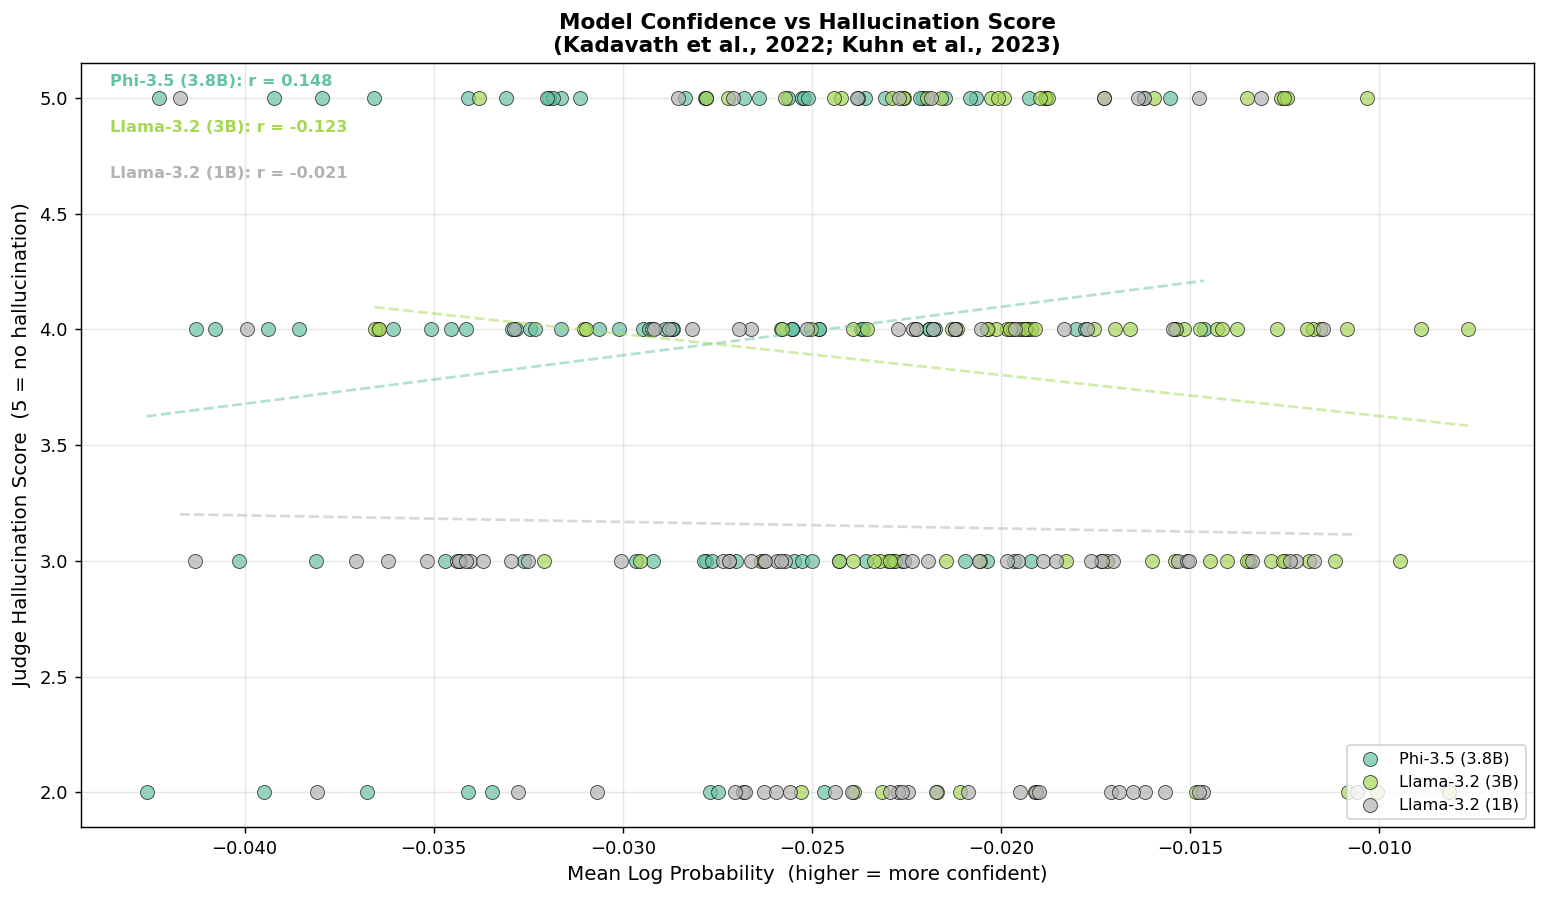

In [211]:
# ── Plot 1: Confidence vs Hallucination scatter ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
for i, label in enumerate(LABELS):
    stats = all_results[label]["sample_stats"]
    x = [s["mean_logprob"]       for s in stats]
    y = [s["judge_hallucination"] for s in stats]
    ax.scatter(x, y, color=COLORS[i], label=label, alpha=0.7, s=60,
               edgecolors="black", linewidth=0.5)
    z  = np.polyfit(x, y, 1)
    xs = np.linspace(min(x), max(x), 100)
    ax.plot(xs, np.poly1d(z)(xs), "--", color=COLORS[i], alpha=0.5, linewidth=1.5)
    r  = all_results[label]["correlation"]["logprob_vs_hallucination"]
    ax.annotate(f"{label}: r = {r:.3f}",
                xy=(0.02, 0.97 - 0.06 * i), xycoords="axes fraction",
                fontsize=9, color=COLORS[i], fontweight="bold")

ax.set_xlabel("Mean Log Probability  (higher = more confident)")
ax.set_ylabel("Judge Hallucination Score  (5 = no hallucination)")
ax.set_title("Model Confidence vs Hallucination Score\n"
             "(Kadavath et al., 2022; Kuhn et al., 2023)", fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "logprob_vs_hallucination.png", dpi=150, bbox_inches="tight")
plt.show()

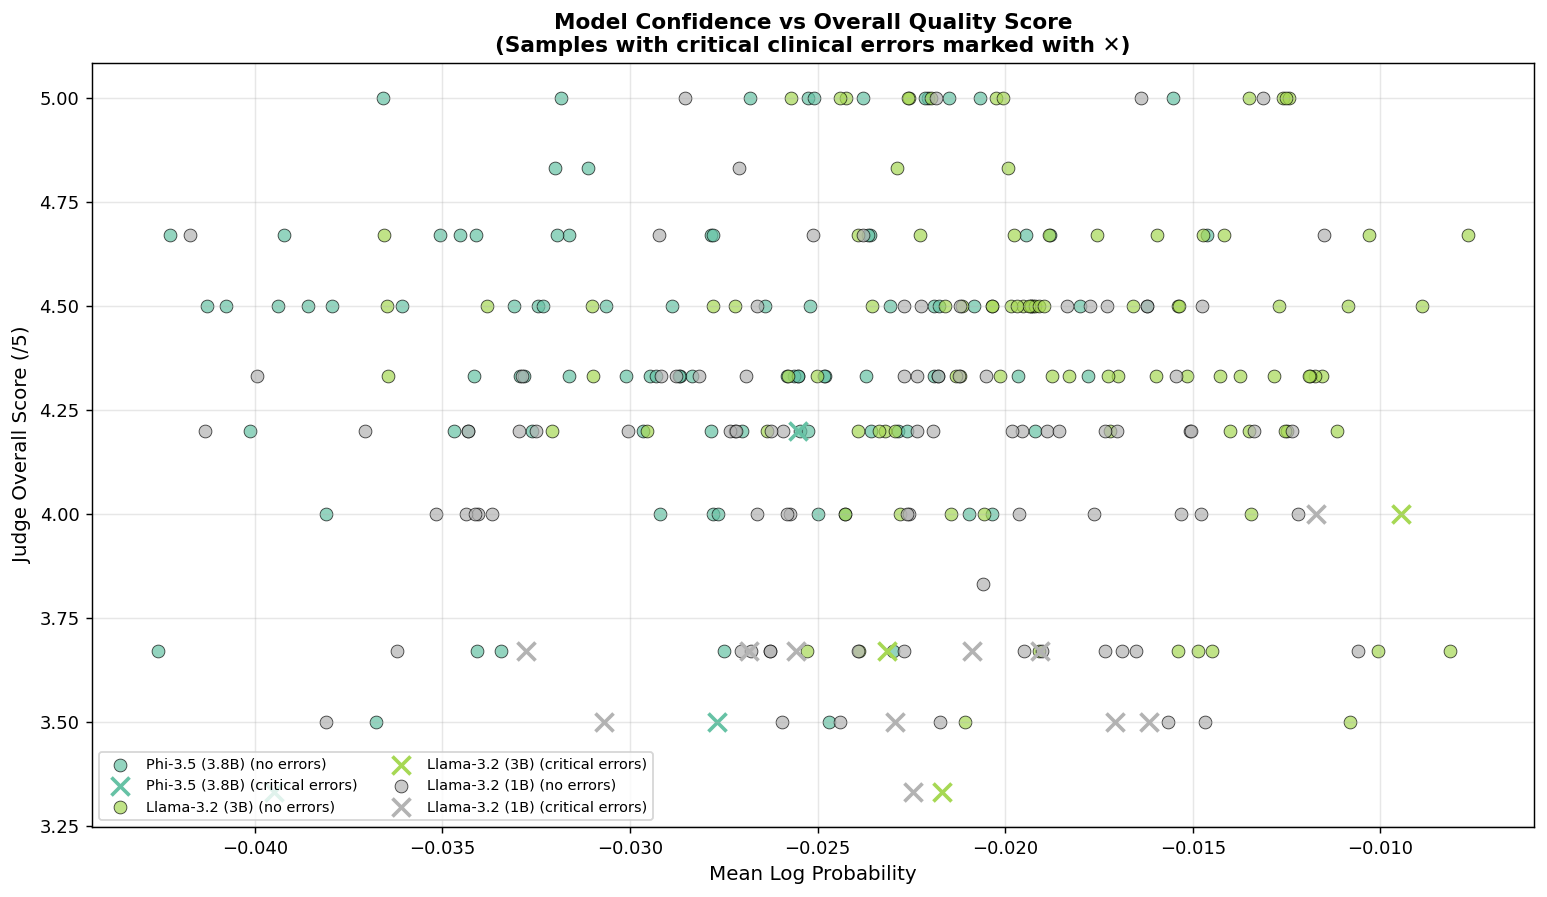

In [212]:
# ── Plot 2: Confidence vs Overall Quality (critical errors marked) ─────────────
fig, ax = plt.subplots(figsize=(12, 7))
for i, label in enumerate(LABELS):
    stats  = all_results[label]["sample_stats"]
    x_vals = [s["mean_logprob"]       for s in stats]
    y_vals = [s["judge_overall"]       for s in stats]
    errors = [s["has_critical_errors"] for s in stats]
    ax.scatter([xv for xv, e in zip(x_vals, errors) if not e],
               [yv for yv, e in zip(y_vals, errors) if not e],
               color=COLORS[i], label=f"{label} (no errors)",
               alpha=0.7, s=50, edgecolors="black", linewidth=0.5)
    if any(errors):
        ax.scatter([xv for xv, e in zip(x_vals, errors) if e],
                   [yv for yv, e in zip(y_vals, errors) if e],
                   color=COLORS[i], marker="x", s=100, linewidths=2,
                   label=f"{label} (critical errors)")

ax.set_xlabel("Mean Log Probability")
ax.set_ylabel("Judge Overall Score (/5)")
ax.set_title("Model Confidence vs Overall Quality Score\n"
             "(Samples with critical clinical errors marked with ✕)", fontweight="bold")
ax.legend(fontsize=8, loc="lower left", ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "logprob_vs_quality.png", dpi=150, bbox_inches="tight")
plt.show()

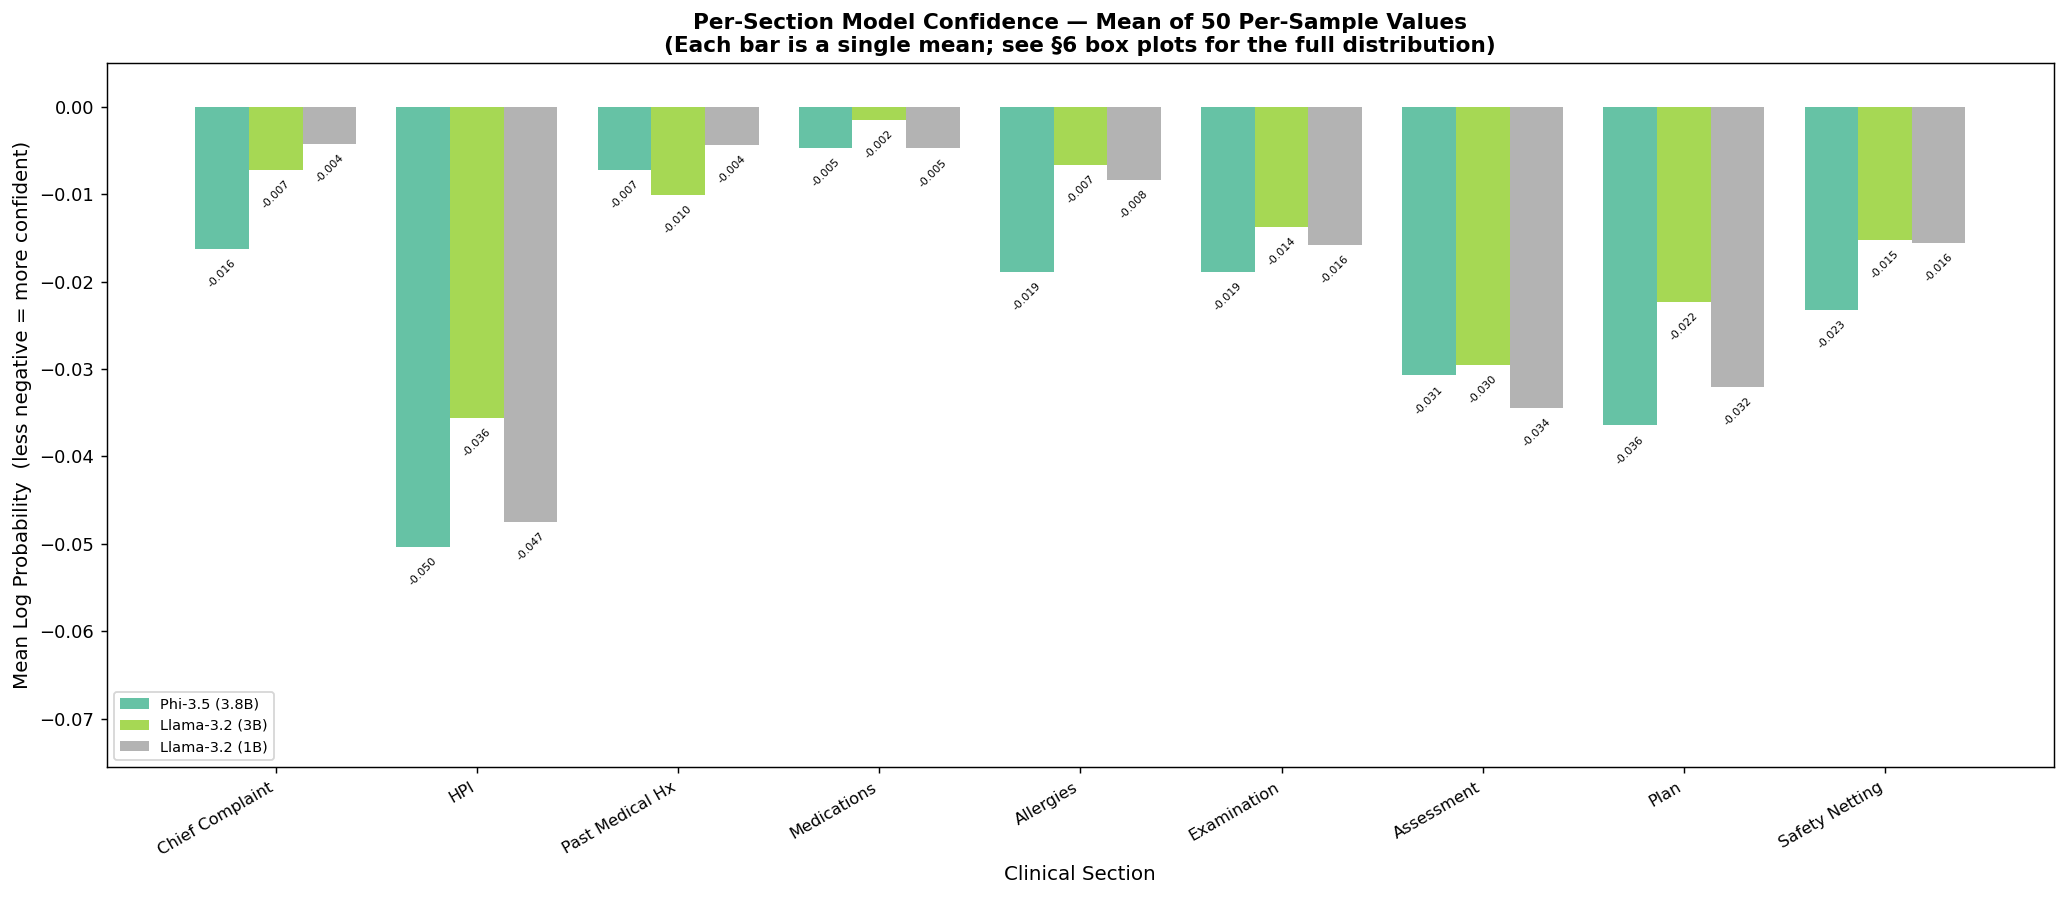

In [213]:
# ── Plot 3: Per-section confidence bar chart (mean across 50 samples) ─────────
section_keys  = [k for k, _ in CLINICAL_SECTIONS]
section_names = [n for _, n in CLINICAL_SECTIONS]
n_models = len(LABELS)
w = 0.8 / n_models

fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(len(section_keys))
all_sec_vals = []
for i, label in enumerate(LABELS):
    sec  = all_results[label]["section_summary"]
    vals = [sec.get(k, {}).get("mean_logprob", 0) for k in section_keys]
    all_sec_vals.extend([v for v in vals if v != 0])
    bars = ax.bar(x + i * w, vals, w, label=label, color=COLORS[i])
    for bar, val in zip(bars, vals):
        if val != 0:
            ax.text(bar.get_x() + bar.get_width() / 2, val - 0.001,
                    f"{val:.3f}", ha="center", va="top", fontsize=6, rotation=45)

ax.set_xticks(x + w * (n_models - 1) / 2)
ax.set_xticklabels(section_names, rotation=30, ha="right", fontsize=9)
ax.set_xlabel("Clinical Section")
ax.set_ylabel("Mean Log Probability  (less negative = more confident)")
ax.set_title("Per-Section Model Confidence — Mean of 50 Per-Sample Values\n"
             "(Each bar is a single mean; see §6 box plots for the full distribution)",
             fontweight="bold")
ax.legend(fontsize=8)
if all_sec_vals:
    ax.set_ylim(min(all_sec_vals) * 1.5, 0.005)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "section_confidence_bar.png", dpi=150, bbox_inches="tight")
plt.show()

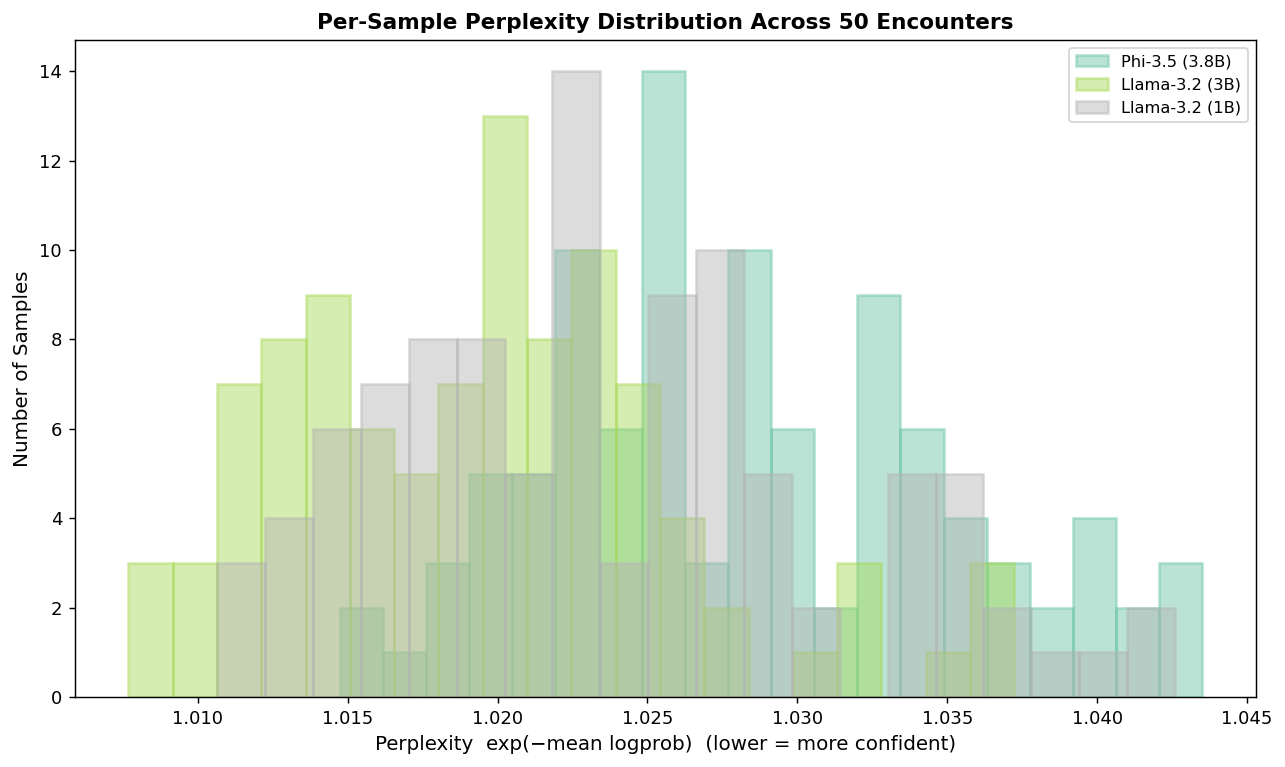

In [214]:
# ── Plot 4: Perplexity distribution histograms ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for i, label in enumerate(LABELS):
    perps = [s["perplexity"] for s in all_results[label]["sample_stats"]]
    ax.hist(perps, bins=20, alpha=0.45, color=COLORS[i],
            label=label, edgecolor=COLORS[i], linewidth=1.5)
ax.set_xlabel("Perplexity  exp(−mean logprob)  (lower = more confident)")
ax.set_ylabel("Number of Samples")
ax.set_title("Per-Sample Perplexity Distribution Across 50 Encounters", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "perplexity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

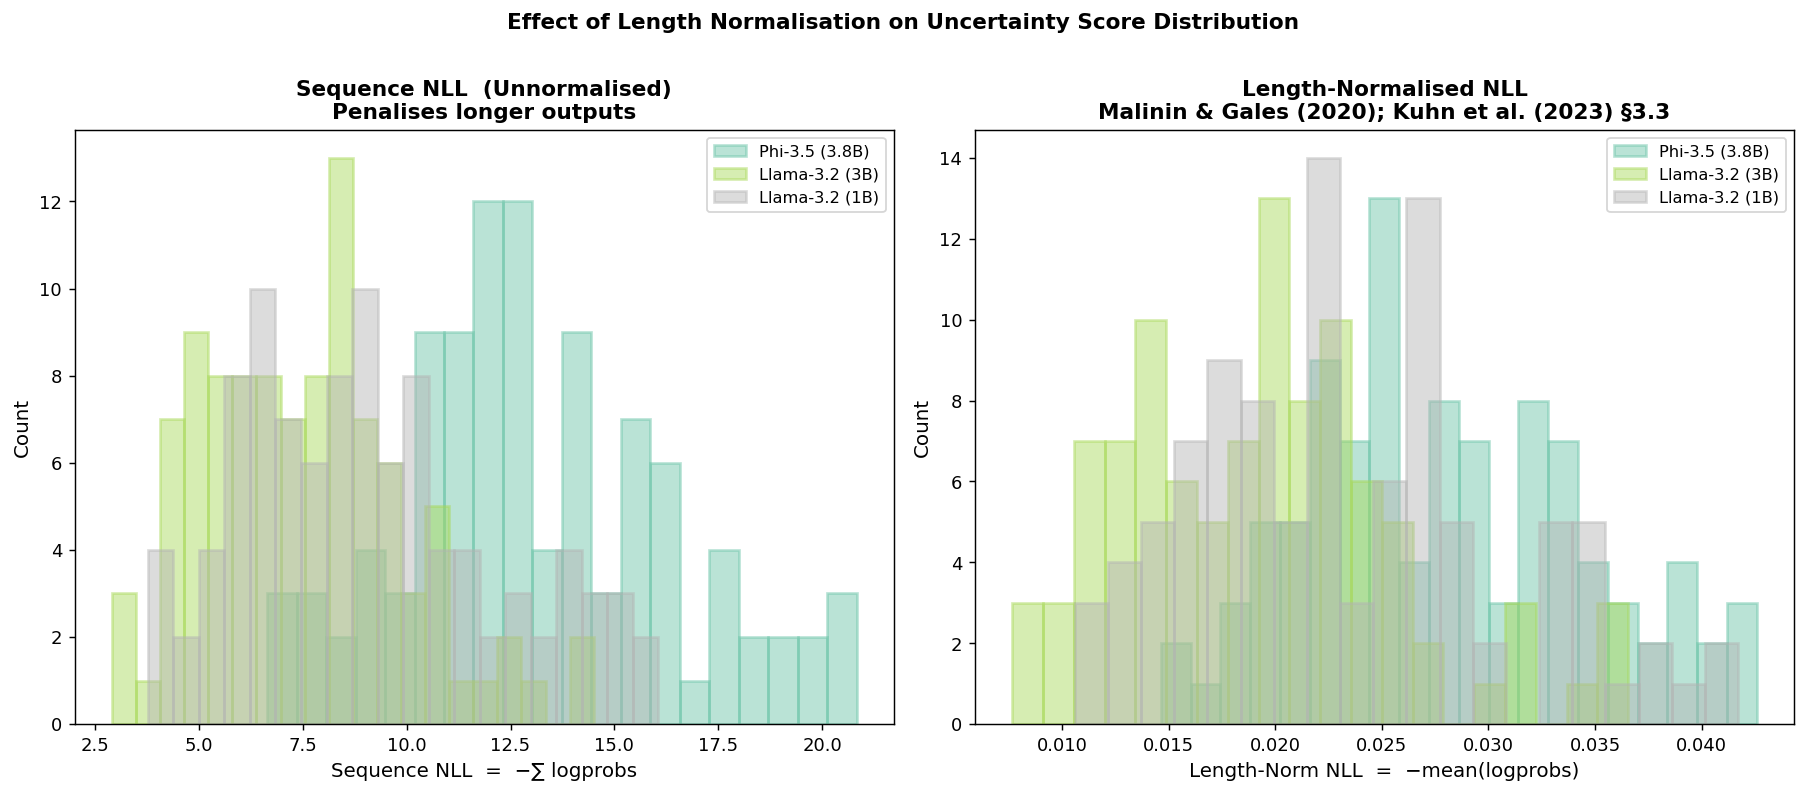

In [215]:
# ── Plot 5: Sequence NLL vs Length-Normalised NLL (effect of normalisation) ───
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, label in enumerate(LABELS):
    stats = all_results[label]["sample_stats"]
    axes[0].hist([s["sequence_nll"]    for s in stats], bins=20, alpha=0.45,
                 color=COLORS[i], label=label, edgecolor=COLORS[i], linewidth=1.5)
    axes[1].hist([s["length_norm_nll"] for s in stats], bins=20, alpha=0.45,
                 color=COLORS[i], label=label, edgecolor=COLORS[i], linewidth=1.5)

axes[0].set_xlabel("Sequence NLL  =  −∑ logprobs"); axes[0].set_ylabel("Count")
axes[0].set_title("Sequence NLL  (Unnormalised)\nPenalises longer outputs",
                  fontweight="bold")
axes[0].legend(fontsize=9)

axes[1].set_xlabel("Length-Norm NLL  =  −mean(logprobs)"); axes[1].set_ylabel("Count")
axes[1].set_title("Length-Normalised NLL\nMalinin & Gales (2020); Kuhn et al. (2023) §3.3",
                  fontweight="bold")
axes[1].legend(fontsize=9)

fig.suptitle("Effect of Length Normalisation on Uncertainty Score Distribution",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "entropy_normalisation.png", dpi=150, bbox_inches="tight")
plt.show()

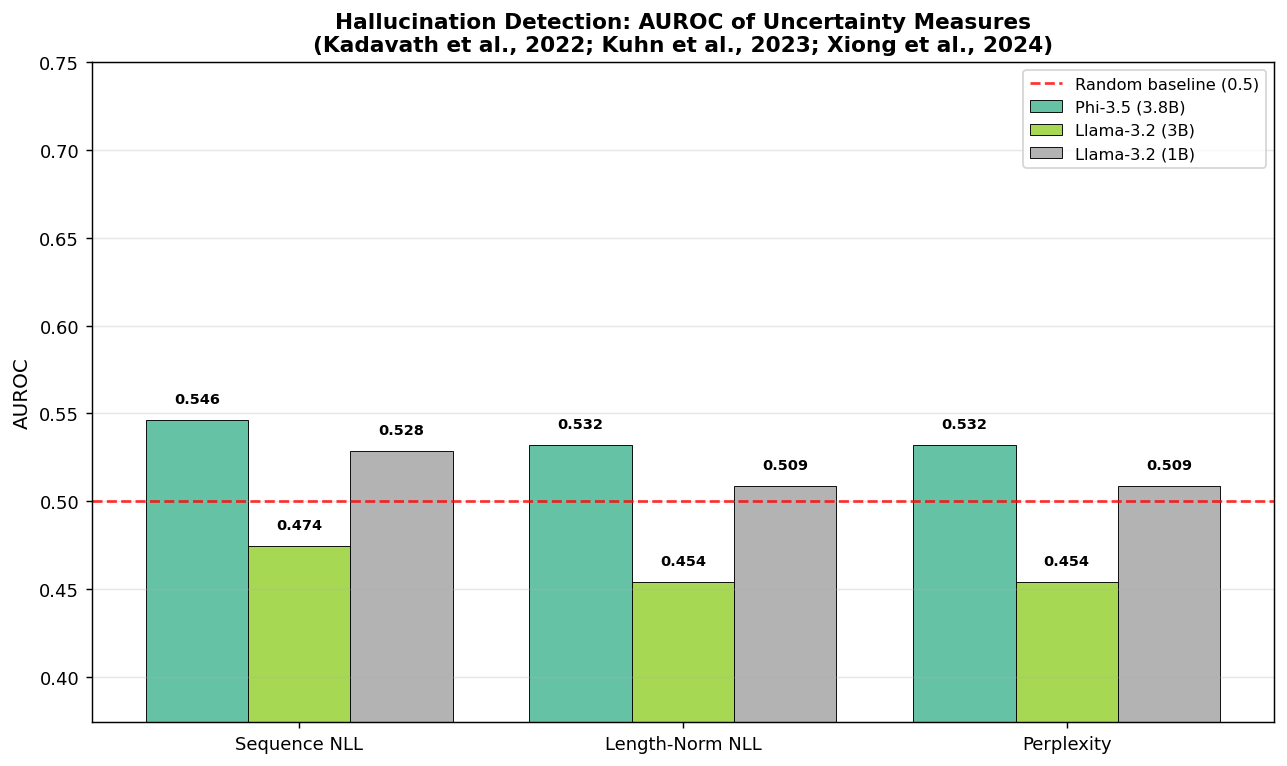

In [216]:

# ── Plot 6: AUROC comparison bar chart ───────────────────────────────────────
methods      = ["sequence_nll", "length_norm_nll", "perplexity"]
method_names = ["Sequence NLL", "Length-Norm NLL", "Perplexity"]
n_models     = len(LABELS)
w            = 0.8 / n_models

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(methods))
all_vals = []
for i, label in enumerate(LABELS):
    auroc_d = all_results[label]["auroc"]
    vals    = [auroc_d[m] for m in methods]
    all_vals.extend(vals)
    bars = ax.bar(x + i * w, vals, w, label=label, color=COLORS[i],
                  edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, vals):
        va = "top"   if val > 0.55 else "bottom"
        y  = bar.get_height() - 0.025 if val > 0.55 else bar.get_height() + 0.008
        fc = "white" if val > 0.55 else "black"
        ax.text(bar.get_x() + bar.get_width() / 2, y, f"{val:.3f}",
                ha="center", va=va, fontsize=8, fontweight="bold", color=fc)

ax.axhline(0.5, color="red", linestyle="--", linewidth=1.5, alpha=0.8,
           label="Random baseline (0.5)")
ax.set_xticks(x + w * (n_models - 1) / 2)
ax.set_xticklabels(method_names, fontsize=10)
ax.set_ylabel("AUROC")
ax.set_title("Hallucination Detection: AUROC of Uncertainty Measures\n"
             "(Kadavath et al., 2022; Kuhn et al., 2023; Xiong et al., 2024)",
             fontweight="bold")
ax.legend(fontsize=9)
# Fixed: was hardcoded to 0.3 which clipped bars below that value (e.g. Llama 3B at 0.269)
ax.set_ylim(max(0.0, min(all_vals) - 0.08), max(max(all_vals) + 0.10, 0.75))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "auroc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


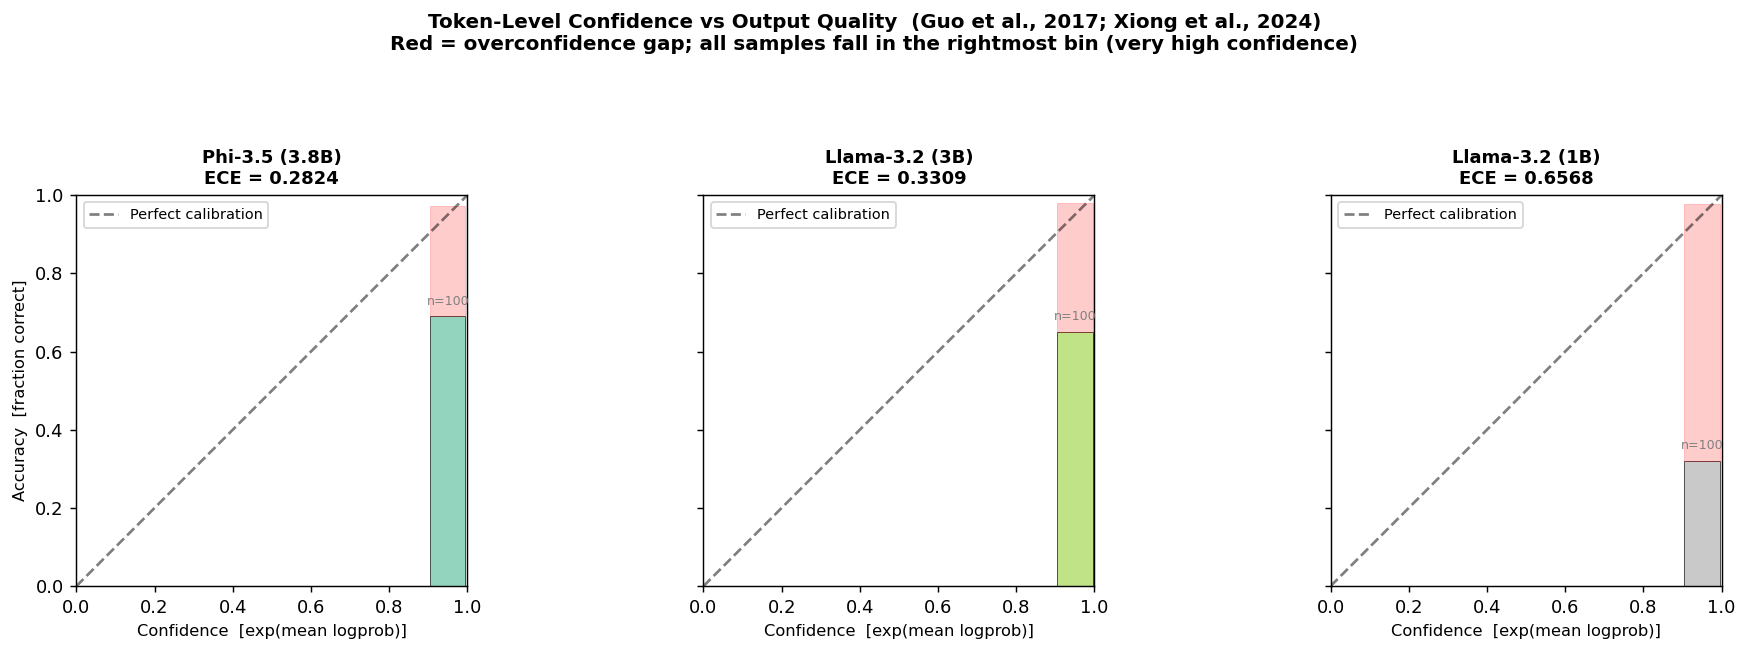

In [217]:

# ── Plot 7: ECE Reliability Diagrams ─────────────────────────────────────────
n_models = len(LABELS)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5), sharey=True)
for i, label in enumerate(LABELS):
    ax       = axes[i]
    ece_d    = all_results[label]["ece"]
    n_bins   = ece_d["n_bins"]
    bar_w    = 1.0 / n_bins
    for j in range(n_bins):
        bc = (j + 0.5) / n_bins
        if ece_d["bin_counts"][j] > 0:
            # Accuracy bar
            ax.bar(bc, ece_d["bin_accuracies"][j], width=bar_w * 0.9,
                   color=COLORS[i], alpha=0.7, edgecolor="black", linewidth=0.5)
            # Red overlay = overconfidence gap
            if ece_d["bin_confidences"][j] > ece_d["bin_accuracies"][j]:
                ax.bar(bc, ece_d["bin_confidences"][j] - ece_d["bin_accuracies"][j],
                       width=bar_w * 0.9, bottom=ece_d["bin_accuracies"][j],
                       color="red", alpha=0.2, edgecolor="red", linewidth=0.5)
            ax.text(bc, ece_d["bin_accuracies"][j] + 0.03,
                    f"n={ece_d['bin_counts'][j]}", ha="center", fontsize=7, color="gray")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
    ax.set_xlabel("Confidence  [exp(mean logprob)]", fontsize=9)
    if i == 0:
        ax.set_ylabel("Accuracy  [fraction correct]", fontsize=9)
    ax.set_title(f"{label}\nECE = {ece_d['ece']:.4f}", fontweight="bold", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle("Token-Level Confidence vs Output Quality  (Guo et al., 2017; Xiong et al., 2024)\n"
             "Red = overconfidence gap; all samples fall in the rightmost bin (very high confidence)",
             fontsize=11, fontweight="bold")
# Fixed: suptitle with y>1.0 gets clipped by tight_layout; use subplots_adjust instead
plt.subplots_adjust(top=0.82)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig(OUTPUT_DIR / "ece_reliability_diagram.png", dpi=150, bbox_inches="tight")
plt.show()


## 6 · Box Plot Analysis

### Why box plots?

The bar charts and scatter plots above each reduce 50 samples to a **single summary value** (mean, or a dot on a scatter). This hides:
- **Variability**: is HPI consistently uncertain, or just occasionally terrible?
- **Outliers**: are there specific encounters where the model was unusually uncertain?
- **Distributions**: is Phi-3.5 more *consistently* confident, or just on average?

The following four box plots address these gaps directly.

| Plot | What it replaces | New information gained |
|---|---|---|
| 6.1 Cross-model metric distributions | Summary table scalars | Spread, skew, outliers per model |
| 6.2 Hallucination score + confidence | The scatter plot | Distribution of hallucination scores; direct AUROC visualisation |
| 6.3 Confidence by quality group | Scatter (discrete rows problem) | Full distribution within correct/incorrect groups → makes AUROC visible |
| 6.4 Per-section confidence distribution | Section mean bar chart | 50-sample distribution per section — are sections consistently or variably uncertain? |

### 6.1 — Cross-Model Uncertainty Metric Distributions

Four panels showing the **distribution of 50 per-sample values** for each key uncertainty metric,
with jittered individual-point overlays. Replaces the single-value summary table.

**What to look for:**
- **Width** of the box: how variable is the model's confidence across encounters?
- **Median vs mean**: are the means in the summary table pulled by outliers?
- **Outliers**: are there specific consultations where the model was dramatically more or less uncertain?

C:\Users\943533.ADIR\AppData\Local\Temp\ipykernel_3224\2202516339.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\943533.ADIR\AppData\Local\Temp\ipykernel_3224\2202516339.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\943533.ADIR\AppData\Local\Temp\ipykernel_3224\2202516339.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\943533.ADIR\AppData\Local\Temp\ipykernel_3224\2202516339.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name 

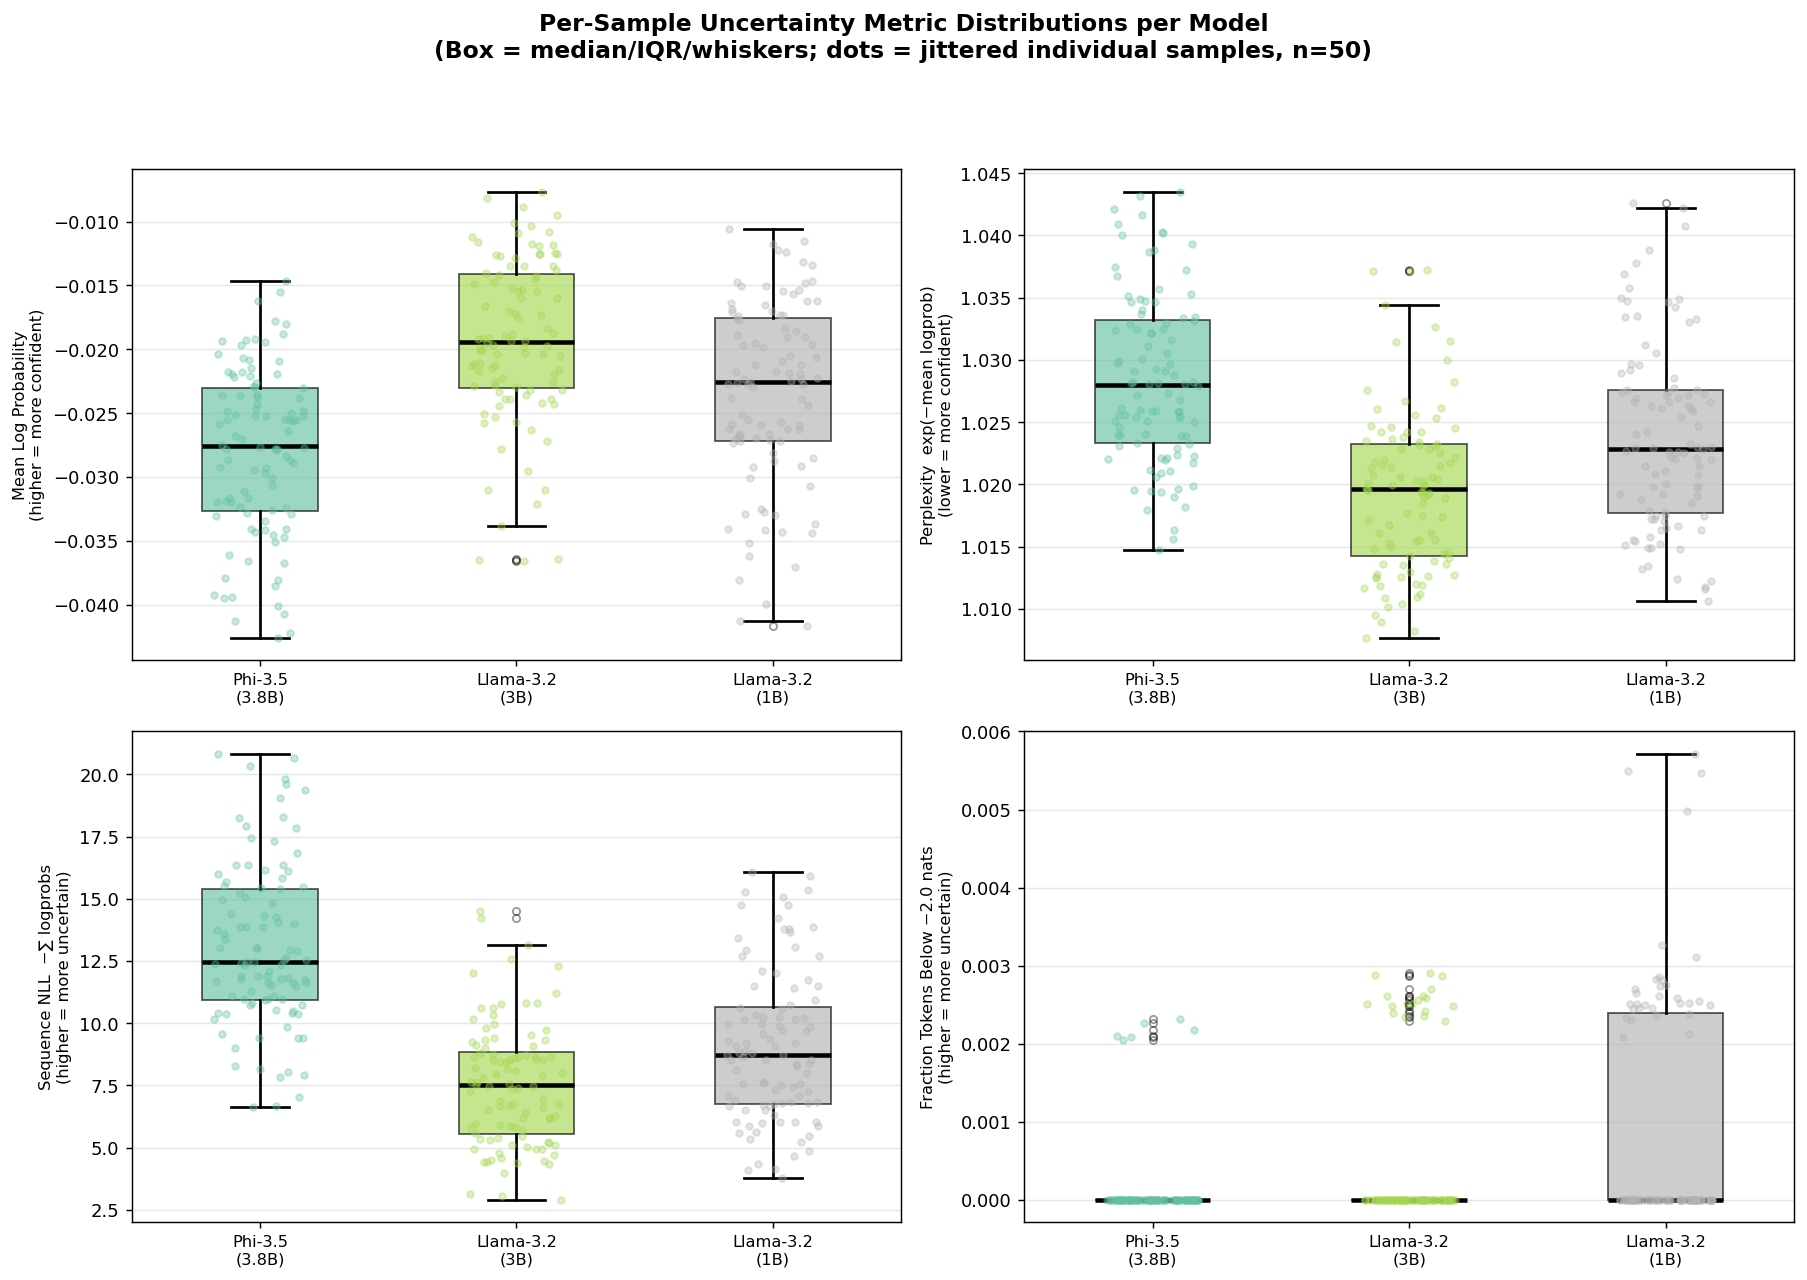

In [218]:

# ── Box Plot 1: 2×2 grid — per-model uncertainty metric distributions ──────────
rng = np.random.default_rng(seed=42)

SHORT_LABELS = ["Phi-3.5\n(3.8B)", "Llama-3.2\n(3B)", "Llama-3.2\n(1B)"]

metrics = [
    ("mean_logprob",   "Mean Log Probability\n(higher = more confident)"),
    ("perplexity",     "Perplexity  exp(−mean logprob)\n(lower = more confident)"),
    ("sequence_nll",   "Sequence NLL  −∑ logprobs\n(higher = more uncertain)"),
    ("frac_low_conf",  "Fraction Tokens Below −2.0 nats\n(higher = more uncertain)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Per-Sample Uncertainty Metric Distributions per Model\n"
             "(Box = median/IQR/whiskers; dots = jittered individual samples, n=50)",
             fontsize=13, fontweight="bold")

for ax, (metric_key, ylabel) in zip(axes.flat, metrics):
    data_per_model = [
        [s[metric_key] for s in all_results[label]["sample_stats"]]
        for label in LABELS
    ]
    bp = ax.boxplot(
        data_per_model,
        labels=SHORT_LABELS,   # shorter labels to avoid overlap
        patch_artist=True,
        medianprops ={"color": "black",  "linewidth": 2.5},
        whiskerprops={"linewidth": 1.5},
        capprops    ={"linewidth": 1.5},
        flierprops  ={"marker": "o", "markersize": 4, "alpha": 0.4},
        widths=0.45,
    )
    for patch, color in zip(bp["boxes"], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    # Jittered individual-point overlay
    for j, (vals, color) in enumerate(zip(data_per_model, COLORS)):
        jitter = rng.uniform(-0.18, 0.18, len(vals))
        ax.scatter(np.full(len(vals), j + 1) + jitter, vals,
                   color=color, alpha=0.35, s=14, zorder=3)

    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(axis="x", labelsize=9)
    ax.grid(axis="y", alpha=0.3)

# Fixed: suptitle with y>1.0 gets clipped; use subplots_adjust to reserve space
plt.subplots_adjust(top=0.92)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(OUTPUT_DIR / "boxplots_uncertainty.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.2 — Hallucination Score Distribution + Mean Confidence per Model

Left axis (box): distribution of LLM-judge hallucination scores (1–5) per model.
Right axis (diamond marker): mean ± 1SD of mean_logprob.

**What to look for:** Do models with lower hallucination scores also report lower confidence? The dashed red line marks the binarisation threshold (score ≤ 3 = hallucinated).

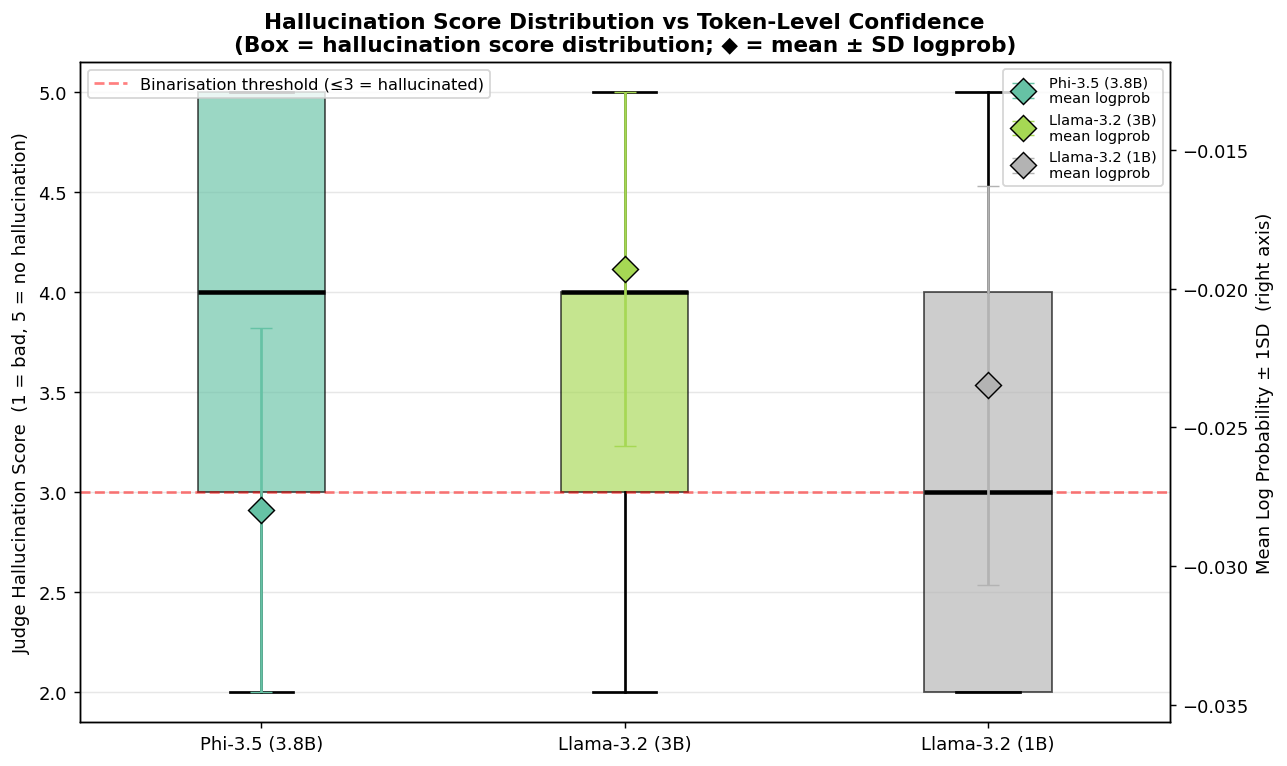

In [219]:
# ── Box Plot 2: Hallucination score distribution + confidence twin axis ────────
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

halluc_data = [
    [s["judge_hallucination"] for s in all_results[label]["sample_stats"]]
    for label in LABELS
]
bp = ax1.boxplot(
    halluc_data,
    positions=range(1, 4), widths=0.35,
    patch_artist=True,
    medianprops ={"color": "black",  "linewidth": 2.5},
    whiskerprops={"linewidth": 1.5},
    capprops    ={"linewidth": 1.5},
    flierprops  ={"marker": "D", "markersize": 5, "alpha": 0.5},
)
for patch, color in zip(bp["boxes"], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.65)

# Right axis: mean ± SD of mean_logprob per model
for j, label in enumerate(LABELS):
    mlps = [s["mean_logprob"] for s in all_results[label]["sample_stats"]]
    ax2.errorbar(j + 1, np.mean(mlps), yerr=np.std(mlps),
                 fmt="D", color=COLORS[j], markersize=10, capsize=6,
                 markeredgecolor="black", markeredgewidth=0.8,
                 zorder=5, label=f"{label}\nmean logprob")

ax1.axhline(3, color="red", linestyle="--", alpha=0.5, linewidth=1.5,
            label="Binarisation threshold (≤3 = hallucinated)")
ax1.set_xticks(range(1, 4))
ax1.set_xticklabels(LABELS, fontsize=10)
ax1.set_ylabel("Judge Hallucination Score  (1 = bad, 5 = no hallucination)", fontsize=10)
ax2.set_ylabel("Mean Log Probability ± 1SD  (right axis)", fontsize=10)
ax1.set_title("Hallucination Score Distribution vs Token-Level Confidence\n"
              "(Box = hallucination score distribution; ◆ = mean ± SD logprob)",
              fontweight="bold")
ax1.legend(fontsize=9, loc="upper left")
ax2.legend(fontsize=8, loc="upper right")
ax1.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "boxplot_hallucination_vs_confidence.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.3 — Confidence Distribution by Output Quality Group (AUROC Visualisation)

**This is the key new plot** requested by the supervisor.

The scatter plot (§5, Plot 1) was uninformative because hallucination scores are discrete integers, causing all 50 points to stack in 5 horizontal rows — the *distribution within* each row was completely invisible.

This plot shows the **full distribution** of the uncertainty score (length-norm NLL) within each quality group, separated per model.

**How to read the AUROC from the boxes:**
- If hallucinated box sits **higher** than non-hallucinated box → AUROC > 0.5 → uncertainty detects hallucinations ✓
- If hallucinated box sits **lower** (or equal) → AUROC ≤ 0.5 → the model is *more confident when it is wrong* ✗
- The **degree of box separation** corresponds directly to the AUROC magnitude

C:\Users\943533.ADIR\AppData\Local\Temp\ipykernel_3224\2876629340.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\943533.ADIR\AppData\Local\Temp\ipykernel_3224\2876629340.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\943533.ADIR\AppData\Local\Temp\ipykernel_3224\2876629340.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


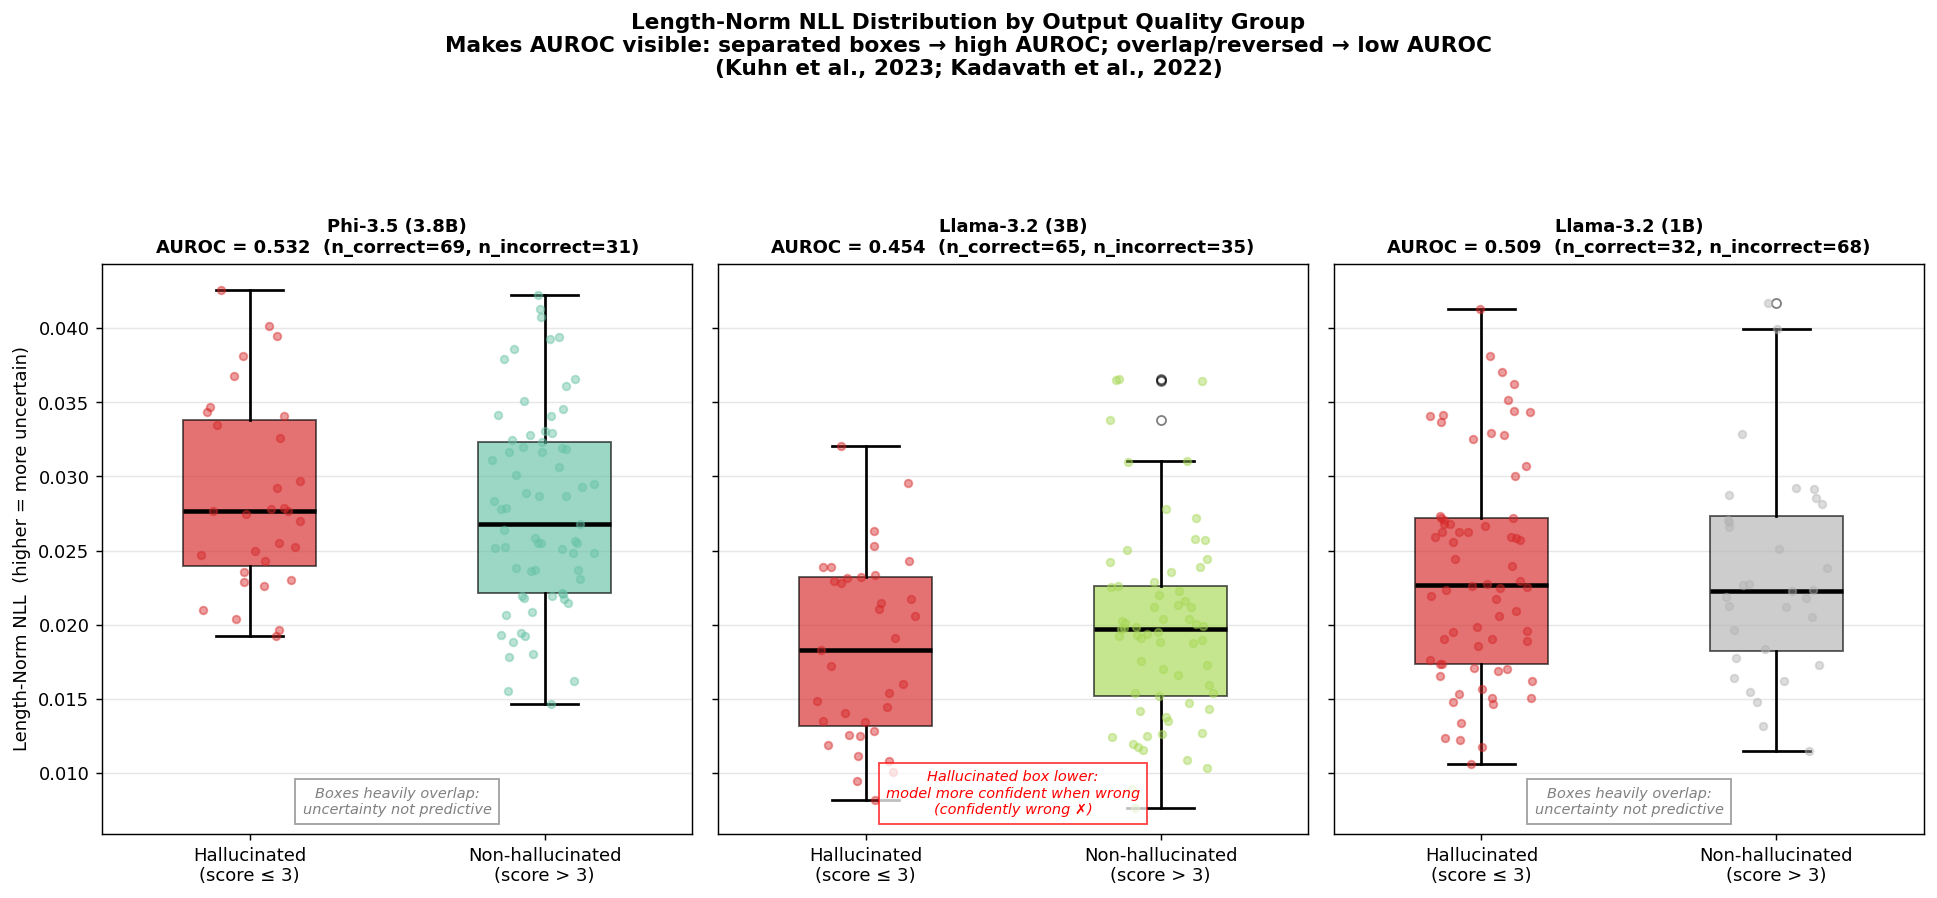

In [220]:

# ── Box Plot 3: NLL distribution by quality group per model (AUROC visible) ────
# Y-axis: Length-Norm NLL (higher = more uncertain — same axis used for AUROC)
# A separated "Hallucinated" box ABOVE "Non-hallucinated" shows AUROC > 0.5.
# A reversed or overlapping pattern shows AUROC ≤ 0.5 (confidently wrong).

rng = np.random.default_rng(seed=42)
n_models = len(LABELS)
fig, axes = plt.subplots(1, n_models, figsize=(15, 7), sharey=True)
fig.suptitle(
    "Length-Norm NLL Distribution by Output Quality Group\n"
    "Makes AUROC visible: separated boxes → high AUROC; overlap/reversed → low AUROC\n"
    "(Kuhn et al., 2023; Kadavath et al., 2022)",
    fontsize=12, fontweight="bold",
)

for i, label in enumerate(LABELS):
    ax    = axes[i]
    stats = all_results[label]["sample_stats"]

    incorrect_nll = [s["length_norm_nll"] for s in stats if s["judge_hallucination"] <= 3]
    correct_nll   = [s["length_norm_nll"] for s in stats if s["judge_hallucination"] >  3]

    bp = ax.boxplot(
        [incorrect_nll, correct_nll],
        labels=["Hallucinated\n(score ≤ 3)", "Non-hallucinated\n(score > 3)"],
        patch_artist=True,
        medianprops ={"color": "black",  "linewidth": 2.5},
        whiskerprops={"linewidth": 1.5},
        capprops    ={"linewidth": 1.5},
        flierprops  ={"marker": "o", "markersize": 5, "alpha": 0.5},
        widths=0.45,
    )
    bp["boxes"][0].set_facecolor("#d62728"); bp["boxes"][0].set_alpha(0.65)  # red = bad
    bp["boxes"][1].set_facecolor(COLORS[i]); bp["boxes"][1].set_alpha(0.65)

    # Jittered individual points
    for j_box, (vals, clr) in enumerate(zip([incorrect_nll, correct_nll],
                                             ["#d62728", COLORS[i]])):
        jitter = rng.uniform(-0.18, 0.18, len(vals))
        ax.scatter(np.full(len(vals), j_box + 1) + jitter, vals,
                   color=clr, alpha=0.45, s=18, zorder=3)

    auroc = all_results[label]["auroc"]["length_norm_nll"]
    n_inc = len(incorrect_nll)
    n_cor = len(correct_nll)
    ax.set_title(
        f"{label}\nAUROC = {auroc:.3f}  (n_correct={n_cor}, n_incorrect={n_inc})",
        fontweight="bold", fontsize=10,
    )
    if i == 0:
        ax.set_ylabel("Length-Norm NLL  (higher = more uncertain)", fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    # Contextual annotation — placed in lower half so it doesn't collide with title
    if auroc > 0.7:
        note = "Hallucinated box higher:\nmodel appropriately uncertain ✓"
        colour = "green"
    elif auroc < 0.5:
        note = "Hallucinated box lower:\nmodel more confident when wrong\n(confidently wrong ✗)"
        colour = "red"
    else:
        note = "Boxes heavily overlap:\nuncertainty not predictive"
        colour = "gray"
    ax.text(0.5, 0.03, note, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=8, color=colour, style="italic",
            bbox=dict(facecolor="white", alpha=0.75, edgecolor=colour, linewidth=1))

# Fixed: suptitle with y>1.0 gets clipped; now placed inside figure with subplots_adjust
plt.subplots_adjust(top=0.85)
plt.tight_layout(rect=[0, 0, 1, 0.87])
plt.savefig(OUTPUT_DIR / "boxplot_quality_groups.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.4 — Per-Section Confidence Distribution Across 50 Samples

**This directly replaces the section mean bar chart.** Each horizontal box shows the distribution of `mean_logprob` values for that clinical section across all 50 encounters. The bar chart above showed only the mean of these 50 values.

**What to look for:**
- **HPI**: should show the widest/lowest distribution (most uncertain, highest encounter-to-encounter variability) — because it requires synthesising a free-form narrative
- **Medications**: should be narrow and close to 0 (deterministic transcription with high confidence)
- **Outlier whiskers**: specific encounters where the model was unusually uncertain about a particular section
- **Cross-model agreement**: do all three models show the same section ordering? If yes, the pattern reflects real task difficulty, not model artefacts

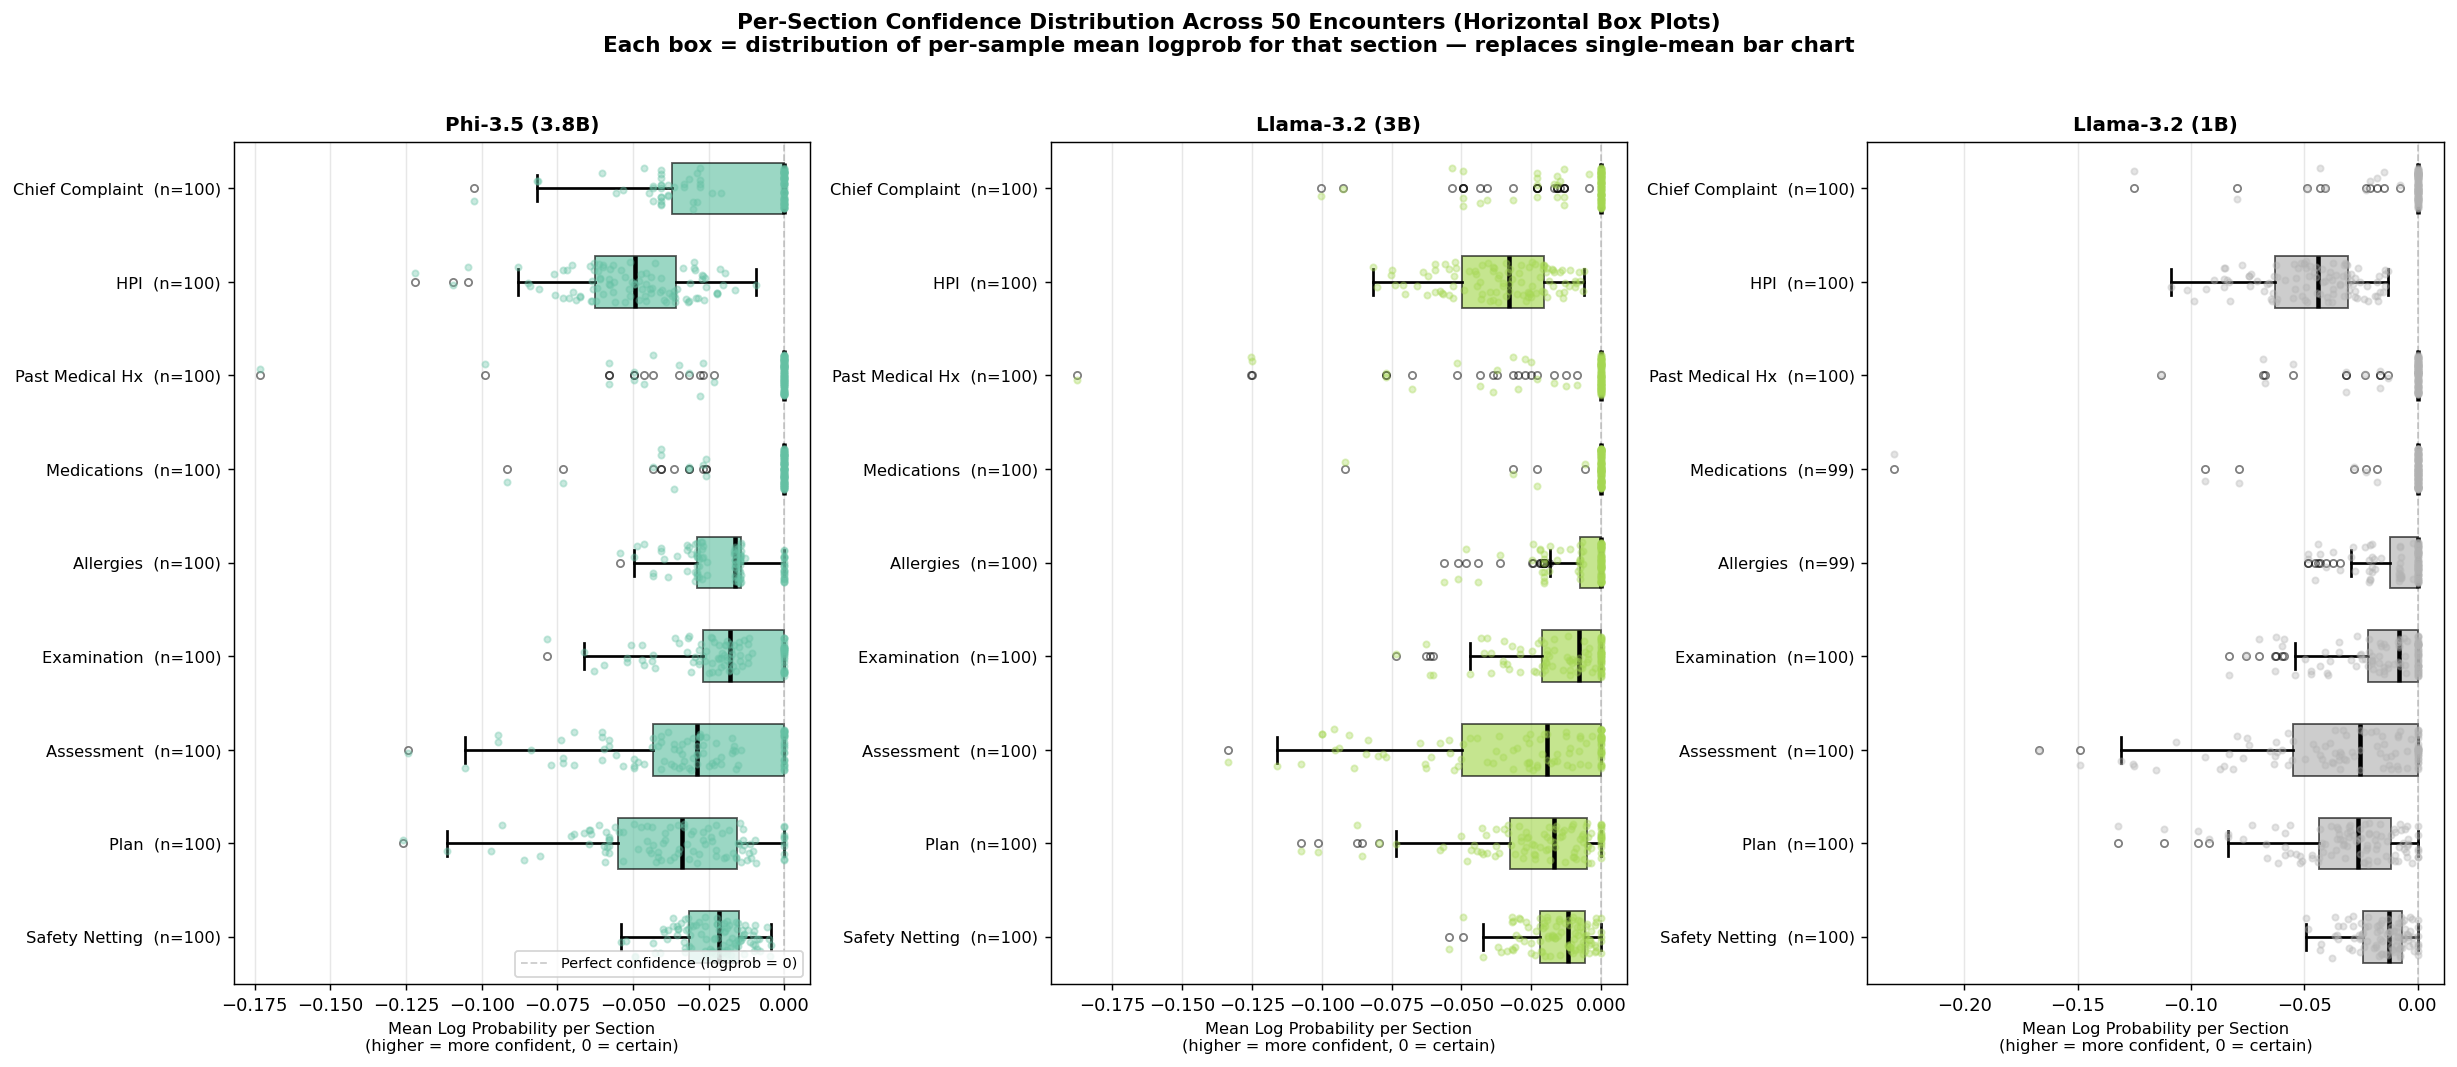

In [221]:
# ── Box Plot 4: Per-section confidence distribution (horizontal, one subplot per model) ──
# Each box = distribution of 50 per-sample mean_logprob values for that section.
# This replaces the single-mean bar chart with full distributional information.

rng = np.random.default_rng(seed=42)
n_models = len(LABELS)
fig, axes = plt.subplots(1, n_models, figsize=(19, 8), sharey=False)
fig.suptitle(
    "Per-Section Confidence Distribution Across 50 Encounters (Horizontal Box Plots)\n"
    "Each box = distribution of per-sample mean logprob for that section — "
    "replaces single-mean bar chart",
    fontsize=12, fontweight="bold", y=1.02,
)

for i, label in enumerate(LABELS):
    ax       = axes[i]
    sec_data = all_section_sample_data[label]

    # Collect data in clinical section order (bottom to top for horizontal layout)
    plot_data:  List[List[float]] = []
    plot_names: List[str]         = []
    for key, name in reversed(CLINICAL_SECTIONS):   # reversed so Chief Complaint is at top
        vals = sec_data.get(key, [])
        if len(vals) >= 3:
            plot_data.append(vals)
            plot_names.append(f"{name}  (n={len(vals)})")

    bp = ax.boxplot(
        plot_data,
        vert=False,
        patch_artist=True,
        medianprops ={"color": "black",  "linewidth": 2.5},
        whiskerprops={"linewidth": 1.5},
        capprops    ={"linewidth": 1.5},
        flierprops  ={"marker": "o", "markersize": 4, "alpha": 0.5},
        widths=0.55,
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(COLORS[i])
        patch.set_alpha(0.65)

    # Jittered individual-point overlay (vert=False → scatter x and y are swapped)
    for j_box, vals in enumerate(plot_data):
        jitter = rng.uniform(-0.22, 0.22, len(vals))
        ax.scatter(vals, np.full(len(vals), j_box + 1) + jitter,
                   color=COLORS[i], alpha=0.35, s=12, zorder=3)

    ax.set_yticks(range(1, len(plot_names) + 1))
    ax.set_yticklabels(plot_names, fontsize=9)
    ax.axvline(0, color="gray", linestyle="--", alpha=0.4, linewidth=1,
               label="Perfect confidence (logprob = 0)")
    ax.set_xlabel("Mean Log Probability per Section\n(higher = more confident, 0 = certain)",
                  fontsize=9)
    ax.set_title(label, fontweight="bold", fontsize=11)
    ax.grid(axis="x", alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "boxplot_section_confidence.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 · Comprehensive Summary Table & Report Export

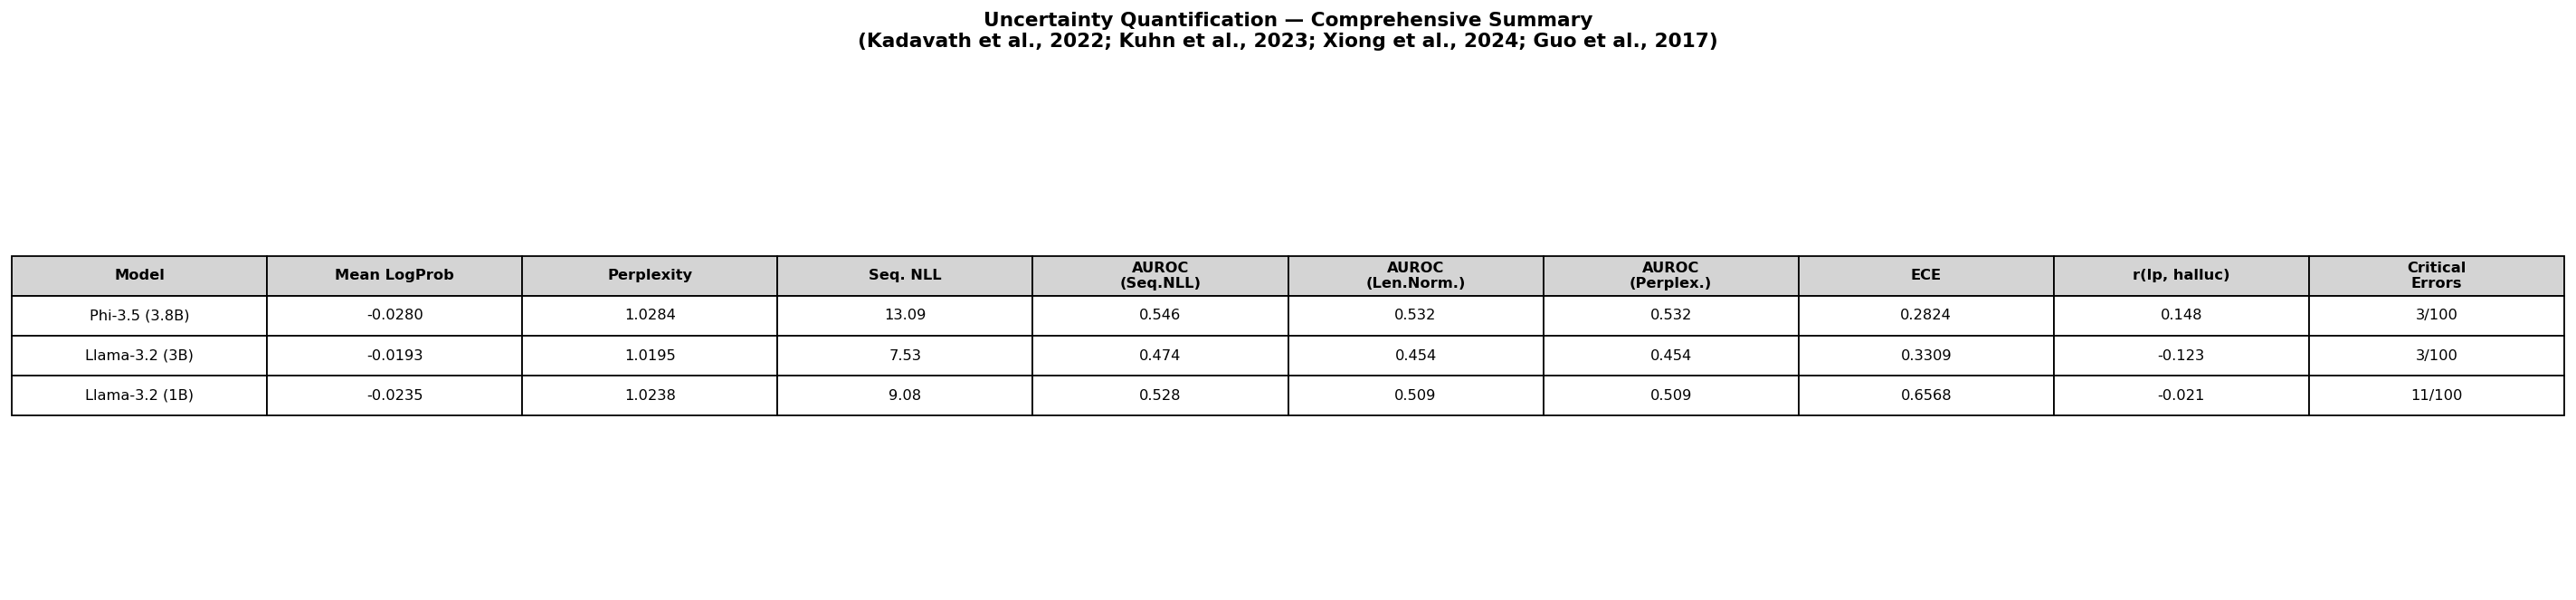

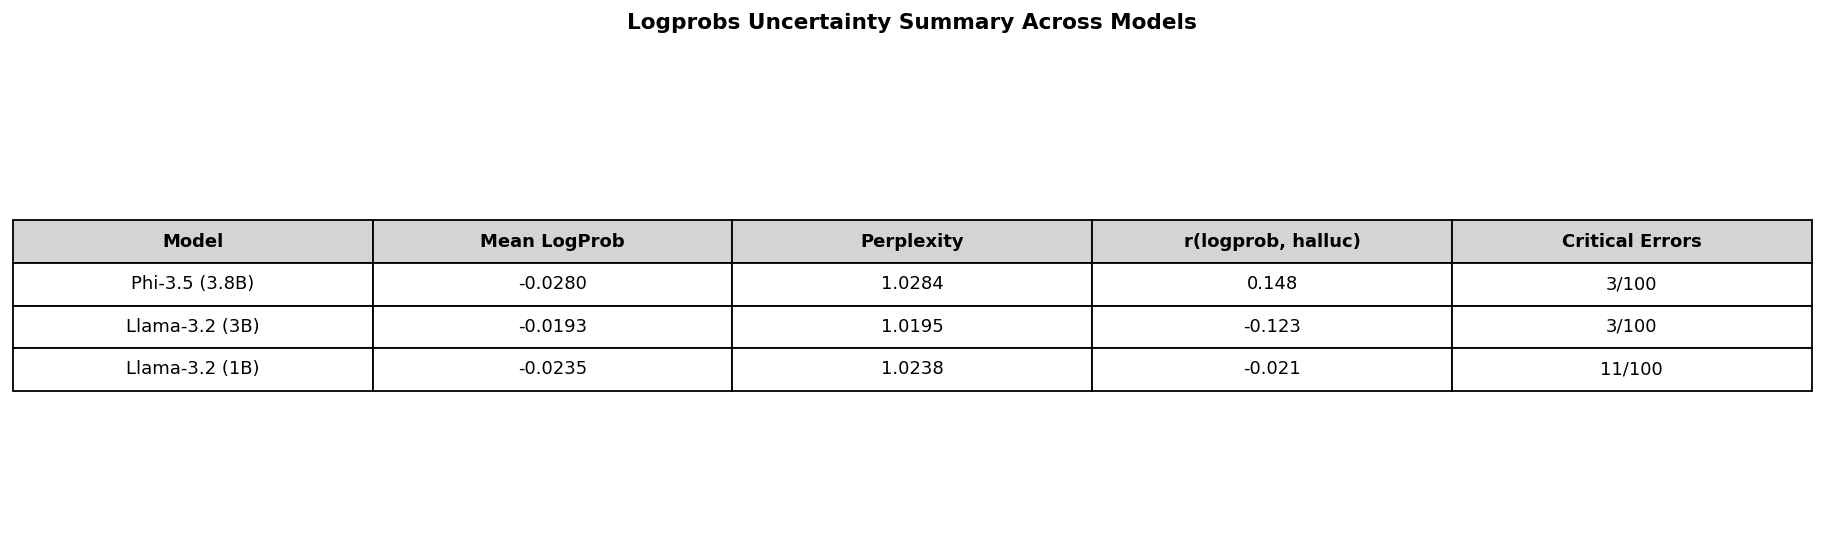

In [222]:
# ── Comprehensive UQ summary table figure ─────────────────────────────────────
col_labels = ["Model", "Mean LogProb", "Perplexity", "Seq. NLL",
              "AUROC\n(Seq.NLL)", "AUROC\n(Len.Norm.)", "AUROC\n(Perplex.)",
              "ECE", "r(lp, halluc)", "Critical\nErrors"]
table_data = []
for label in LABELS:
    d      = all_results[label]
    stats  = d["sample_stats"]
    auroc  = d["auroc"]
    ece    = d["ece"]
    corr   = d["correlation"]
    mlps   = [s["mean_logprob"] for s in stats]
    perps  = [s["perplexity"]   for s in stats]
    seqnll = [s["sequence_nll"] for s in stats]
    n_err  = sum(1 for s in stats if s["has_critical_errors"])
    table_data.append([
        label,
        f"{np.mean(mlps):.4f}",
        f"{np.mean(perps):.4f}",
        f"{np.mean(seqnll):.2f}",
        f"{auroc['sequence_nll']:.3f}",
        f"{auroc['length_norm_nll']:.3f}",
        f"{auroc['perplexity']:.3f}",
        f"{ece['ece']:.4f}",
        f"{corr['logprob_vs_hallucination']:.3f}",
        f"{n_err}/{len(stats)}",
    ])

fig, ax = plt.subplots(figsize=(22, 2.5 + len(LABELS) * 0.9))
ax.axis("off")
table = ax.table(cellText=table_data, colLabels=col_labels,
                 loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.9)
for j in range(len(col_labels)):
    table[0, j].set_text_props(fontweight="bold")
    table[0, j].set_facecolor("#D4D4D4")

ax.set_title("Uncertainty Quantification — Comprehensive Summary\n"
             "(Kadavath et al., 2022; Kuhn et al., 2023; Xiong et al., 2024; Guo et al., 2017)",
             fontsize=12, fontweight="bold", pad=22)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "uq_comprehensive_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Simpler summary table ──────────────────────────────────────────────────────
simple_cols = ["Model", "Mean LogProb", "Perplexity", "r(logprob, halluc)", "Critical Errors"]
simple_data = []
for label in LABELS:
    d   = all_results[label]; stats = d["sample_stats"]
    mlps = [s["mean_logprob"] for s in stats]; perps = [s["perplexity"] for s in stats]
    n_err = sum(1 for s in stats if s["has_critical_errors"])
    simple_data.append([label, f"{np.mean(mlps):.4f}", f"{np.mean(perps):.4f}",
                         f"{d['correlation']['logprob_vs_hallucination']:.3f}",
                         f"{n_err}/{len(stats)}"])

fig2, ax2 = plt.subplots(figsize=(14, 2.0 + len(LABELS) * 0.8))
ax2.axis("off")
t2 = ax2.table(cellText=simple_data, colLabels=simple_cols, loc="center", cellLoc="center")
t2.auto_set_font_size(False); t2.set_fontsize(10); t2.scale(1.2, 1.8)
for j in range(len(simple_cols)):
    t2[0, j].set_text_props(fontweight="bold"); t2[0, j].set_facecolor("#D4D4D4")
ax2.set_title("Logprobs Uncertainty Summary Across Models", fontsize=12, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "logprobs_summary_table.png", dpi=150, bbox_inches="tight")
plt.show()

In [223]:
# ── Markdown report export ─────────────────────────────────────────────────────
lines = [
    "# Uncertainty Quantification Analysis via Log Probabilities",
    "",
    "## Scientific Background",
    "",
    "Token-level log probabilities provide a measure of model confidence for each "
    "generated token. Lower logprobs indicate higher uncertainty, which has been shown "
    "to correlate with factual errors and hallucinations (Kadavath et al., 2022; Kuhn et al., 2023).",
    "",
]

for label in LABELS:
    d      = all_results[label]
    stats  = d["sample_stats"]
    sec    = d["section_summary"]
    auroc  = d["auroc"]
    ece    = d["ece"]
    corr   = d["correlation"]
    mlps   = [s["mean_logprob"]   for s in stats]
    perps  = [s["perplexity"]     for s in stats]
    flcf   = [s["frac_low_conf"]  for s in stats]

    lines += [
        f"## {label}", "",
        "### Overall Confidence", "",
        "| Metric | Value |", "|---|---|",
        f"| Mean logprob | {np.mean(mlps):.4f} |",
        f"| Std logprob | {np.std(mlps):.4f} |",
        f"| Mean perplexity | {np.mean(perps):.4f} |",
        f"| Mean frac low-conf tokens | {np.mean(flcf):.4f} |",
        f"| Num samples | {len(stats)} |",
        f"| Correlation (logprob vs hallucination) | {corr['logprob_vs_hallucination']:.4f} |",
        f"| Correlation (logprob vs overall quality) | {corr['logprob_vs_overall']:.4f} |",
        "",
        "### Hallucination Detection AUROC",
        "",
        "AUROC = 0.5 → random; AUROC = 1.0 → perfect detection. "
        "Binarisation: judge_hallucination > 3 = correct "
        "(Kuhn et al., 2023; Xiong et al., 2024).",
        "",
        "| Uncertainty Measure | AUROC | Interpretation |",
        "|---|---|---|",
        f"| Sequence NLL | {auroc['sequence_nll']:.4f} | "
        f"{'Useful' if auroc['sequence_nll'] > 0.6 else 'Near-random'} |",
        f"| Length-Norm NLL | {auroc['length_norm_nll']:.4f} | "
        f"{'Useful' if auroc['length_norm_nll'] > 0.6 else 'Near-random'} |",
        f"| Perplexity | {auroc['perplexity']:.4f} | "
        f"{'Useful' if auroc['perplexity'] > 0.6 else 'Near-random'} |",
        f"| N correct / N incorrect | {auroc['n_correct']} / {auroc['n_incorrect']} | |",
        "",
        "### Calibration (ECE)",
        "",
        "**Caveat:** Token-level confidence = exp(mean_logprob) reflects how probable the model "
        "considers its own token choices, NOT the probability of factual correctness. "
        "A model can produce high-probability hallucinations. "
        "ECE quantifies the overconfidence gap (Guo et al., 2017).",
        "",
        f"| ECE | {ece['ece']:.4f} |",
        "",
        "### Per-Section Confidence",
        "",
        "| Section | Mean LogProb | Perplexity | Frac Low-Conf | N Samples |",
        "|---|---|---|---|---|",
    ]
    for key, name in CLINICAL_SECTIONS:
        if key in sec:
            s = sec[key]
            lines.append(f"| {name} | {s['mean_logprob']:.4f} | "
                         f"{s['mean_perplexity']:.4f} | {s['mean_frac_low_conf']:.4f} | "
                         f"{s['num_samples']} |")
    lines.append("")

report_path = OUTPUT_DIR / "logprobs_report.md"
report_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Report saved to: {report_path}")
print(f"\nAll outputs saved to: {OUTPUT_DIR}")
print("\nFiles generated:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name}")

Report saved to: d:\ambient-scribe\notebooks\logprobs_analysis_output\logprobs_report.md

All outputs saved to: d:\ambient-scribe\notebooks\logprobs_analysis_output

Files generated:
  auprc_curves.png
  auroc_comparison.png
  boxplot_hallucination_vs_confidence.png
  boxplot_quality_groups.png
  boxplot_section_confidence.png
  boxplots_uncertainty.png
  completeness_vs_uncertainty.png
  critical_errors_count.png
  ece_reliability_diagram.png
  entropy_normalisation.png
  length_vs_uncertainty.png
  logprob_vs_hallucination.png
  logprob_vs_quality.png
  logprobs_report.md
  logprobs_summary_table.png
  multidim_auroc_heatmap.png
  perplexity_distribution.png
  section_confidence_bar.png
  table_uq_uncertainty.md
  threshold_sensitivity.png
  token_aggregation_auroc.png
  uq_comprehensive_summary.png


## 8 · Extra Analyses

I ran a few extra checks after comparing my approach to the Kuhn et al. (2023) and Xiong et al. (2024) papers. These didn't fit neatly into the main analysis but they address some real limitations I found:

1. **Length vs NLL** — Phi-3.5 had much higher Sequence NLL than Llama 3B. I want to check if that's just because it writes longer transcripts, which would inflate the sum of log-losses by definition.
2. **Threshold sensitivity** — I chose `hallucination > 3` as my "correct" cutoff. Does the AUROC conclusion change if I use a looser (> 2) or stricter (> 4) threshold? If the model ranking stays the same, the conclusion is robust.
3. **Worst-case token uncertainty** — the average logprob might miss one very uncertain sentence buried in otherwise confident text. Does using the worst 10th percentile of tokens work better as a signal?
4. **AUPRC** — AUROC can be misleading when one class dominates. Llama 1B had 34/50 = 68% hallucinated samples, so even a naive classifier could look reasonable. AUPRC handles imbalance better (Xiong et al., 2024, Table 5 also reports this).
5. **Multi-dimensional AUROC** — the judge scored 6 dimensions, not just hallucination. Does logprob uncertainty predict failures on completeness, safety, accuracy too?
6. **Completeness vs uncertainty** — if the model was uncertain about a section, did it just write less? I check whether `frac_low_conf` correlates with the completeness score.
7. **Critical errors text** — instead of just flagging yes/no, I read the actual error descriptions and check whether the model was less confident on those samples.

r(output length, uncertainty metric):

Model                    r(len, seq_NLL)   r(len, ln_NLL)   mean length
------------------------------------------------------------------------
Phi-3.5 (3.8B)                    0.3233          -0.0077           468
Llama-3.2 (3B)                    0.0309          -0.2140           393
Llama-3.2 (1B)                    0.4106           0.1321           385


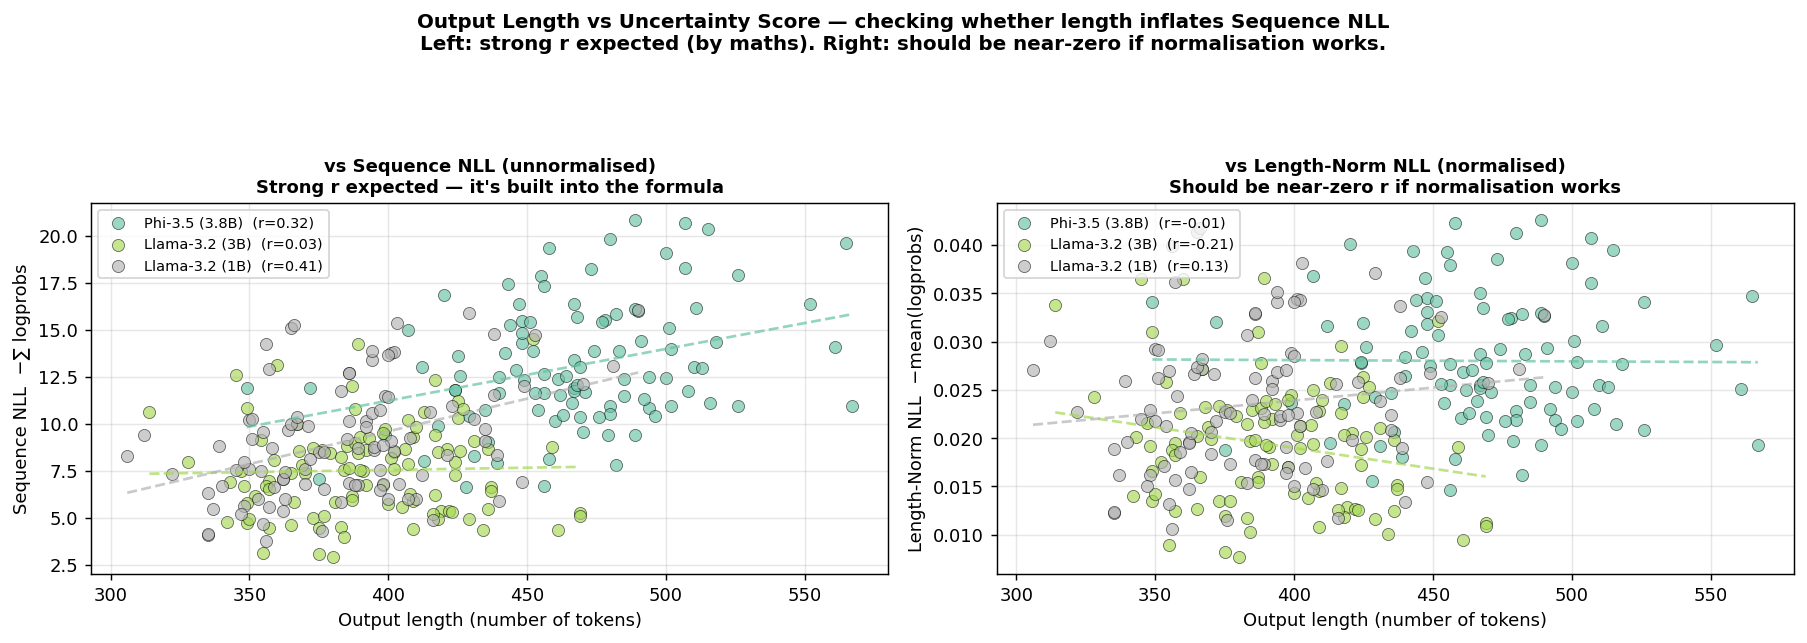


If r(len, seq_NLL) >> r(len, ln_NLL) → length explains the difference between models,
confirming that length-norm NLL (not seq_NLL) is the right metric to compare across models.


In [224]:

# ── 8.1: Does output length explain Phi's high Sequence NLL? ──────────────────
# Phi-3.5 had a much higher Sequence NLL (~37) compared to Llama 3B (~19).
# But Sequence NLL = sum of all token log-losses, so longer outputs always get
# higher total NLL even if per-token confidence is the same.
# Left plot: length vs seq_NLL — strong r expected (built into the maths).
# Right plot: length vs length-norm NLL — should be near zero if normalisation works.
# If the right r is near zero, the Phi "difference" in seq_NLL is just a length artefact
# and length-norm NLL is the correct metric to use for cross-model comparison.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Output Length vs Uncertainty Score — checking whether length inflates Sequence NLL\n"
    "Left: strong r expected (by maths). Right: should be near-zero if normalisation works.",
    fontsize=11, fontweight="bold"
)

print("r(output length, uncertainty metric):\n")
print(f"{'Model':<22} {'r(len, seq_NLL)':>17} {'r(len, ln_NLL)':>16} {'mean length':>13}")
print("-" * 72)

for i, label in enumerate(LABELS):
    stats   = all_results[label]["sample_stats"]
    lengths = [s["num_tokens"]      for s in stats]
    seq_n   = [s["sequence_nll"]    for s in stats]
    ln_n    = [s["length_norm_nll"] for s in stats]

    r_seq = float(np.corrcoef(lengths, seq_n)[0, 1])
    r_ln  = float(np.corrcoef(lengths, ln_n)[0, 1])
    print(f"{label:<22} {r_seq:>17.4f} {r_ln:>16.4f} {np.mean(lengths):>13.0f}")

    for ax_idx, (y_vals, r_val) in enumerate([(seq_n, r_seq), (ln_n, r_ln)]):
        ax = axes[ax_idx]
        ax.scatter(lengths, y_vals, color=COLORS[i], alpha=0.65, s=45,
                   label=f"{label}  (r={r_val:.2f})", edgecolors="black", linewidth=0.4)
        z  = np.polyfit(lengths, y_vals, 1)
        xs = np.linspace(min(lengths), max(lengths), 100)
        ax.plot(xs, np.poly1d(z)(xs), "--", color=COLORS[i], alpha=0.7, linewidth=1.5)

axes[0].set_xlabel("Output length (number of tokens)", fontsize=10)
axes[0].set_ylabel("Sequence NLL  −∑ logprobs", fontsize=10)
axes[0].set_title("vs Sequence NLL (unnormalised)\nStrong r expected — it's built into the formula",
                  fontweight="bold", fontsize=10)
axes[0].legend(fontsize=8, loc="upper left")
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Output length (number of tokens)", fontsize=10)
axes[1].set_ylabel("Length-Norm NLL  −mean(logprobs)", fontsize=10)
axes[1].set_title("vs Length-Norm NLL (normalised)\nShould be near-zero r if normalisation works",
                  fontweight="bold", fontsize=10)
axes[1].legend(fontsize=8, loc="upper left")
axes[1].grid(alpha=0.3)

plt.subplots_adjust(top=0.82)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig(OUTPUT_DIR / "length_vs_uncertainty.png", dpi=150, bbox_inches="tight")
plt.show()
print()
print("If r(len, seq_NLL) >> r(len, ln_NLL) → length explains the difference between models,")
print("confirming that length-norm NLL (not seq_NLL) is the right metric to compare across models.")


AUROC (Length-Norm NLL) at different binarisation thresholds:

Model                   AUROC (>2)  AUROC (>3)  AUROC (>4)   N correct (>2)   (>3)   (>4)
---------------------------------------------------------------------------------------
Phi-3.5 (3.8B)              0.7364      0.5320      0.5588               92     69     32
Llama-3.2 (3B)              0.4544      0.4541      0.4293               90     65     24
Llama-3.2 (1B)              0.4350      0.5087      0.5792               72     32     11

Stable ranking across all three thresholds → result is robust to this choice.
Big swings → the binarisation cutoff matters and needs more justification in writeup.


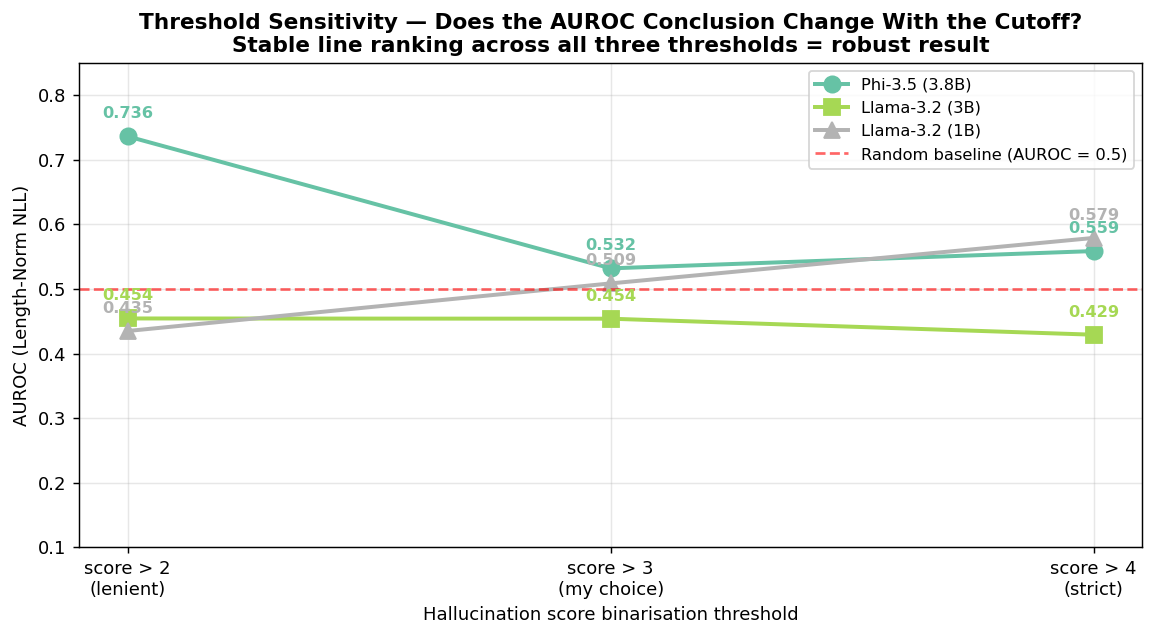

In [225]:

# ── 8.2: Does my AUROC depend heavily on the threshold I chose? ───────────────
# I binarised hallucination scores as: > 3 = correct, ≤ 3 = hallucinated.
# The judge gives integer scores 1–5 so a score of exactly 3 is borderline.
# I'm checking whether my conclusion changes if I use a looser threshold (> 2)
# or a stricter one (> 4). If the model ranking stays the same across all three,
# my result doesn't depend on this one choice — it's robust.

thresholds = [2, 3, 4]
threshold_auroc = {label: {} for label in LABELS}

print("AUROC (Length-Norm NLL) at different binarisation thresholds:\n")
print(f"{'Model':<22} {'AUROC (>2)':>11} {'AUROC (>3)':>11} {'AUROC (>4)':>11}  "
      f"{'N correct (>2)':>15} {'(>3)':>6} {'(>4)':>6}")
print("-" * 87)

for label in LABELS:
    stats   = all_results[label]["sample_stats"]
    ln_nlls = [s["length_norm_nll"]      for s in stats]
    halluc  = [s["judge_hallucination"]  for s in stats]

    row_aurocs = []
    row_ns     = []
    for th in thresholds:
        is_ok  = [h > th for h in halluc]
        bin_lb = [0 if ok else 1 for ok in is_ok]
        auroc  = compute_auroc(ln_nlls, bin_lb)
        row_aurocs.append(auroc)
        row_ns.append(sum(is_ok))
        threshold_auroc[label][th] = auroc

    print(f"{label:<22} {row_aurocs[0]:>11.4f} {row_aurocs[1]:>11.4f} {row_aurocs[2]:>11.4f}  "
          f"{row_ns[0]:>15} {row_ns[1]:>6} {row_ns[2]:>6}")

print()
print("Stable ranking across all three thresholds → result is robust to this choice.")
print("Big swings → the binarisation cutoff matters and needs more justification in writeup.")

fig, ax = plt.subplots(figsize=(9, 5))
markers = ["o", "s", "^"]
for i, label in enumerate(LABELS):
    auroc_vals = [threshold_auroc[label][th] for th in thresholds]
    ax.plot(thresholds, auroc_vals, "-", color=COLORS[i], marker=markers[i],
            markersize=9, linewidth=2.2, label=label)
    for th, av in zip(thresholds, auroc_vals):
        ax.annotate(f"{av:.3f}", xy=(th, av), xytext=(0, 10),
                    textcoords="offset points", ha="center",
                    fontsize=9, color=COLORS[i], fontweight="bold")

ax.axhline(0.5, color="red", linestyle="--", alpha=0.6, linewidth=1.5,
           label="Random baseline (AUROC = 0.5)")
ax.set_xticks(thresholds)
ax.set_xticklabels(
    [f"score > {t}\n({'lenient' if t == 2 else 'my choice' if t == 3 else 'strict'})"
     for t in thresholds], fontsize=10
)
ax.set_xlabel("Hallucination score binarisation threshold", fontsize=10)
ax.set_ylabel("AUROC (Length-Norm NLL)", fontsize=10)
ax.set_title("Threshold Sensitivity — Does the AUROC Conclusion Change With the Cutoff?\n"
             "Stable line ranking across all three thresholds = robust result",
             fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0.1, 0.85)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "threshold_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()


AUROC using different ways of summarising token logprobs:

Model                    mean (current)   p10 (bot.10%)   min (worst tok)   frac_low_conf
----------------------------------------------------------------------------------------
Phi-3.5 (3.8B)                   0.5320          0.5000            0.5764          0.5259
Llama-3.2 (3B)                   0.4541          0.5000            0.4582          0.4684
Llama-3.2 (1B)                   0.5087          0.5000            0.3929          0.3913

p10 = catches hidden pockets of uncertainty (10% most uncertain tokens)
min = highly sensitive — but a single tokenisation artefact can dominate
frac = counts how often the model dipped below 13.5% token probability


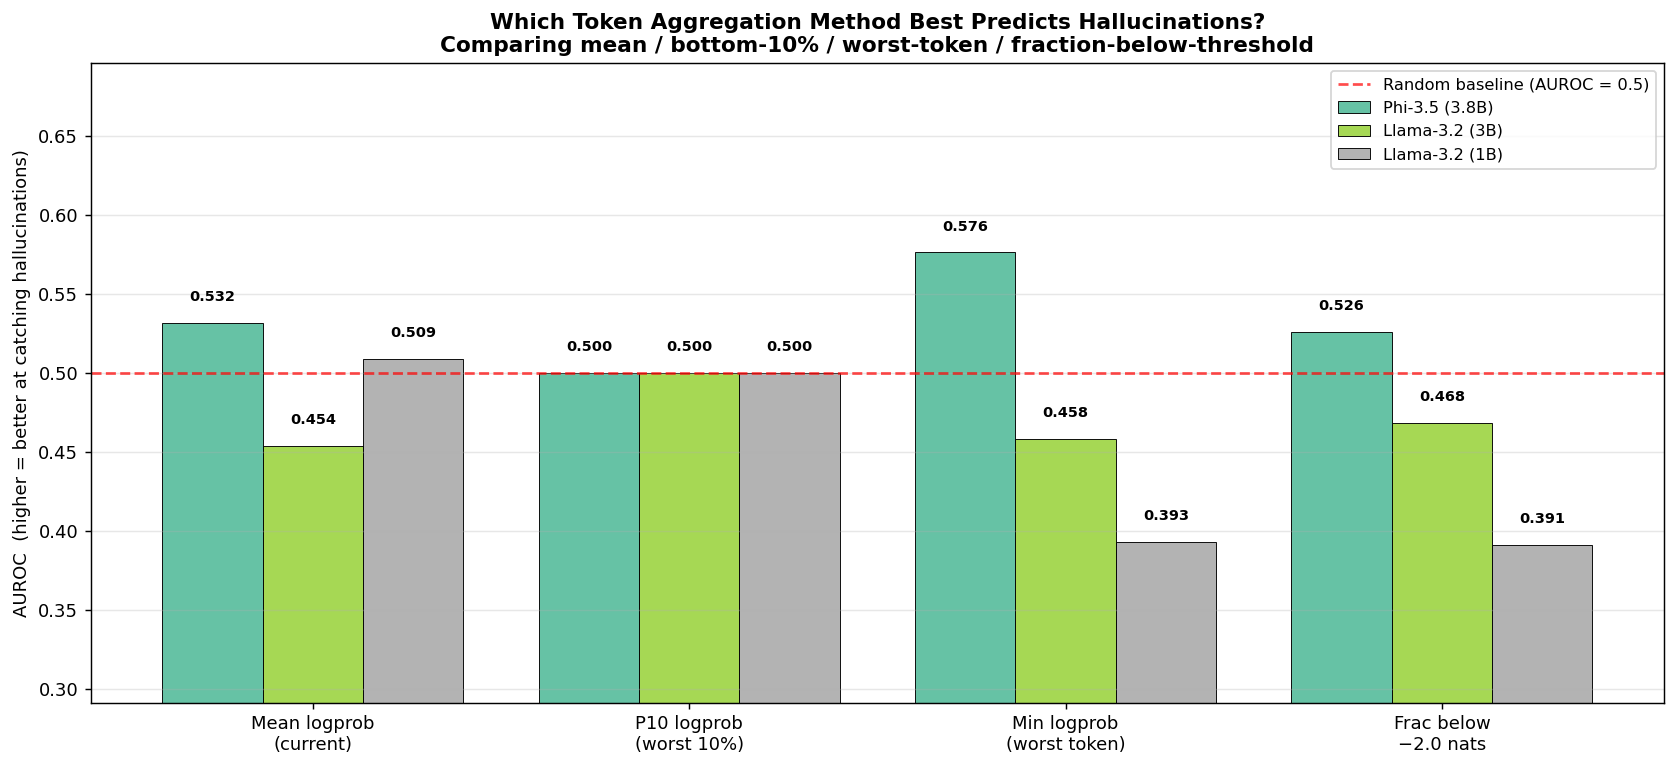

In [226]:

# ── 8.3: Is the average token logprob the best signal, or should I use the worst? ─
# I've been using mean_logprob (= −length_norm_NLL) as my uncertainty score.
# But what if a model hallucinated in one specific sentence while being confident
# everywhere else? The average gets pulled up by all the confident tokens and misses it.
#
# I'm testing three alternatives:
#   p10_logprob  = bottom 10th percentile — captures the worst 10% of tokens
#   min_logprob  = single worst token in the whole output
#   frac_low_conf = fraction of tokens that dipped below −2.0 nats (< 13.5% prob)
#
# For AUROC: I negate logprob-based scores because lower logprob = higher uncertainty.

print("AUROC using different ways of summarising token logprobs:\n")
print(f"{'Model':<22} {'mean (current)':>16} {'p10 (bot.10%)':>15} "
      f"{'min (worst tok)':>17} {'frac_low_conf':>15}")
print("-" * 88)

auroc_strategies = {}
for label in LABELS:
    stats      = all_results[label]["sample_stats"]
    halluc     = [s["judge_hallucination"] for s in stats]
    bin_labels = [0 if h > 3 else 1 for h in halluc]

    scores_mean = [s["length_norm_nll"]  for s in stats]   # already is −mean_logprob
    scores_p10  = [-s["p10_logprob"]     for s in stats]   # negate: lower logprob = more uncertain
    scores_min  = [-s["min_logprob"]     for s in stats]   # single worst token
    scores_frac = [s["frac_low_conf"]    for s in stats]   # higher = more uncertain

    a_mean = compute_auroc(scores_mean, bin_labels)
    a_p10  = compute_auroc(scores_p10,  bin_labels)
    a_min  = compute_auroc(scores_min,  bin_labels)
    a_frac = compute_auroc(scores_frac, bin_labels)
    auroc_strategies[label] = {"mean": a_mean, "p10": a_p10, "min": a_min, "frac": a_frac}

    print(f"{label:<22} {a_mean:>16.4f} {a_p10:>15.4f} {a_min:>17.4f} {a_frac:>15.4f}")

print()
print("p10 = catches hidden pockets of uncertainty (10% most uncertain tokens)")
print("min = highly sensitive — but a single tokenisation artefact can dominate")
print("frac = counts how often the model dipped below 13.5% token probability")

strategy_keys  = ["mean", "p10", "min", "frac"]
strategy_names = ["Mean logprob\n(current)", "P10 logprob\n(worst 10%)",
                  "Min logprob\n(worst token)", "Frac below\n−2.0 nats"]
w = 0.8 / len(LABELS)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(strategy_keys))
all_auc_vals = []

for i, label in enumerate(LABELS):
    vals = [auroc_strategies[label][k] for k in strategy_keys]
    all_auc_vals.extend(vals)
    bars = ax.bar(x + i * w, vals, w, label=label, color=COLORS[i],
                  edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, vals):
        inside = val > 0.58
        ypos   = bar.get_height() - 0.03 if inside else bar.get_height() + 0.012
        col    = "white" if inside else "black"
        va     = "top" if inside else "bottom"
        ax.text(bar.get_x() + bar.get_width() / 2, ypos, f"{val:.3f}",
                ha="center", va=va, fontsize=8, fontweight="bold", color=col)

ax.axhline(0.5, color="red", linestyle="--", linewidth=1.5, alpha=0.7,
           label="Random baseline (AUROC = 0.5)")
ax.set_xticks(x + w * (len(LABELS) - 1) / 2)
ax.set_xticklabels(strategy_names, fontsize=10)
ax.set_ylabel("AUROC  (higher = better at catching hallucinations)", fontsize=10)
ax.set_title("Which Token Aggregation Method Best Predicts Hallucinations?\n"
             "Comparing mean / bottom-10% / worst-token / fraction-below-threshold",
             fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(max(0.0, min(all_auc_vals) - 0.10), min(1.0, max(all_auc_vals) + 0.12))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "token_aggregation_auroc.png", dpi=150, bbox_inches="tight")
plt.show()


AUPRC (uncertainty = Length-Norm NLL, binary label = hallucinated):

Model                     AUPRC    AUROC   Baseline  Above baseline?
----------------------------------------------------------------------
Phi-3.5 (3.8B)           0.3680   0.5320     0.3100            Yes ✓
Llama-3.2 (3B)           0.3340   0.4541     0.3500      Barely / No
Llama-3.2 (1B)           0.6971   0.5087     0.6800      Barely / No


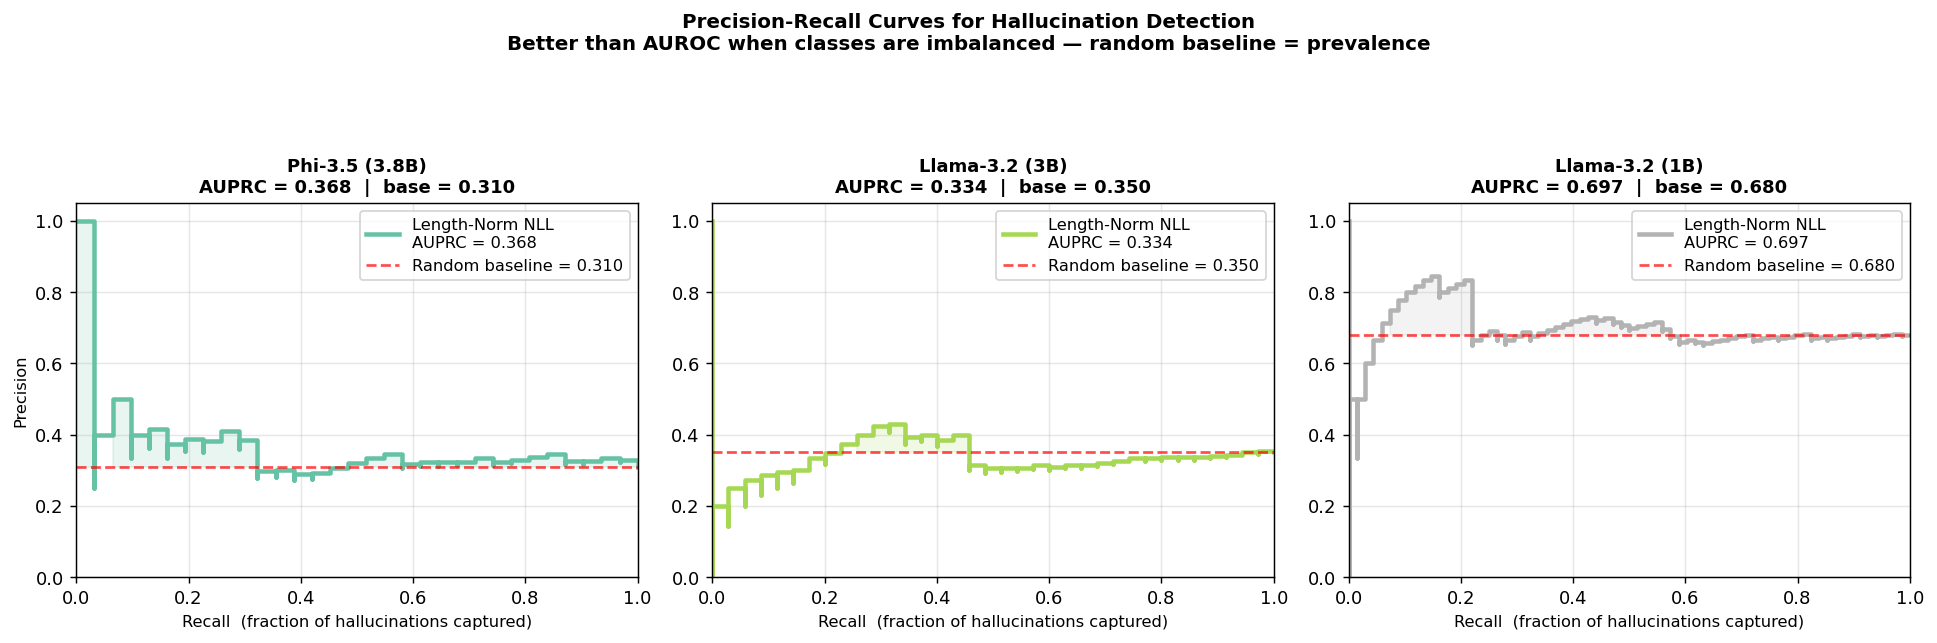


AUPRC >> baseline → logprob uncertainty provides real predictive power.
AUPRC ≈ baseline → no better than randomly flagging the prevalent class.


In [227]:

# ── 8.4: AUPRC — a fairer metric when one class dominates ───────────────────────
# AUROC can be misleading when hallucinated and correct samples are very unequal.
# Example: Llama 1B had ~34/50 = 68% hallucinated — a classifier that flags
# everything scores AUROC ≈ 0.5, but AUPRC would match the prevalence.
# The random AUPRC baseline = prevalence (not 0.5), so I need to clearly beat that.
# Xiong et al. (2024) Table 5 reported both AUROC and AUPRC for this exact reason.

try:
    from sklearn.metrics import precision_recall_curve, average_precision_score
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False
    print("sklearn not available — install it or skip this cell.")

if HAS_SKLEARN:
    print("AUPRC (uncertainty = Length-Norm NLL, binary label = hallucinated):\n")
    print(f"{'Model':<22} {'AUPRC':>8} {'AUROC':>8} {'Baseline':>10} {'Above baseline?':>16}")
    print("-" * 70)

    fig, axes = plt.subplots(1, len(LABELS), figsize=(5 * len(LABELS), 5))
    fig.suptitle(
        "Precision-Recall Curves for Hallucination Detection\n"
        "Better than AUROC when classes are imbalanced — random baseline = prevalence",
        fontsize=11, fontweight="bold"
    )

    for i, label in enumerate(LABELS):
        ax     = axes[i]
        stats  = all_results[label]["sample_stats"]
        halluc = [s["judge_hallucination"] for s in stats]
        bin_labels = [0 if h > 3 else 1 for h in halluc]
        scores = [s["length_norm_nll"] for s in stats]

        prevalence = float(np.mean(bin_labels))
        precision, recall, _ = precision_recall_curve(bin_labels, scores)
        auprc = float(average_precision_score(bin_labels, scores))
        auroc = all_results[label]["auroc"]["length_norm_nll"]

        ax.step(recall, precision, where="post", color=COLORS[i], linewidth=2.5,
                label=f"Length-Norm NLL\nAUPRC = {auprc:.3f}")
        ax.axhline(prevalence, color="red", linestyle="--", alpha=0.7, linewidth=1.5,
                   label=f"Random baseline = {prevalence:.3f}")
        ax.fill_between(recall, precision, prevalence,
                        where=(precision >= prevalence), step="post",
                        alpha=0.15, color=COLORS[i])

        above = "Yes ✓" if auprc > prevalence + 0.05 else "Barely / No"
        print(f"{label:<22} {auprc:>8.4f} {auroc:>8.4f} {prevalence:>10.4f} {above:>16}")

        ax.set_xlabel("Recall  (fraction of hallucinations captured)", fontsize=9)
        if i == 0:
            ax.set_ylabel("Precision", fontsize=9)
        ax.set_title(f"{label}\nAUPRC = {auprc:.3f}  |  base = {prevalence:.3f}",
                     fontweight="bold", fontsize=10)
        ax.legend(fontsize=9, loc="upper right")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)

    plt.subplots_adjust(top=0.82)
    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.savefig(OUTPUT_DIR / "auprc_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print()
    print("AUPRC >> baseline → logprob uncertainty provides real predictive power.")
    print("AUPRC ≈ baseline → no better than randomly flagging the prevalent class.")


AUROC by judge dimension (ln_NLL uncertainty, binary: score ≤ 3 = failure):

Dimension                  Phi-3.5 (3.8B)     Llama-3.2 (3B)     Llama-3.2 (1B)
-------------------------------------------------------------------------------
Hallucination                      0.5320             0.4541             0.5087
Clinical Accuracy                  0.6813             0.4242             0.4499
Completeness                 all-same cls       all-same cls       all-same cls
Clinical Safety                    0.9495             0.6768       all-same cls
Coherence                    all-same cls       all-same cls       all-same cls
Conciseness                  all-same cls       all-same cls             0.6162

> 0.6 = uncertainty useful  |  ≈ 0.5 = random  |  < 0.5 = confidently wrong


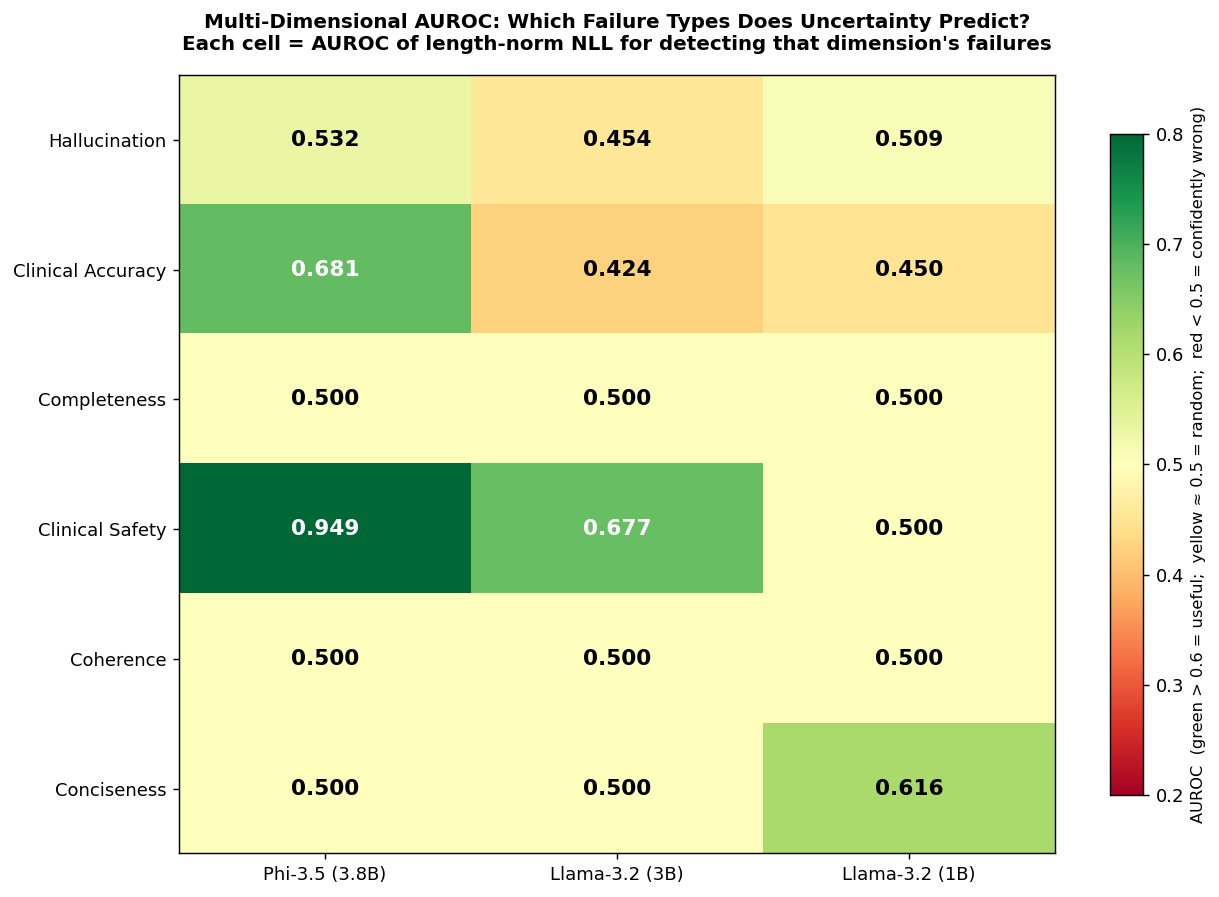

In [228]:

# ── 8.5: Does uncertainty predict failure on ALL judge dimensions? ─────────────
# So far I've only checked hallucination. The judge scored 6 dimensions:
#   hallucination, clinical_accuracy, completeness, clinical_safety,
#   coherence, conciseness.
#
# Hypothesis: if logprob uncertainty predicts failures on MULTIPLE dimensions,
# it's a general signal of output quality — not just a hallucination detector.
# If it only gets hallucination right, it means the model "knows" when it makes
# things up, but not when it's incomplete or incoherent.
#
# For each cell: AUROC of length_norm_nll at predicting failure on that dimension.
# "failure" threshold is the same as for hallucination: score ≤ 3.

JUDGE_DIMS = [
    ("judge_hallucination", "Hallucination"),
    ("judge_accuracy",      "Clinical Accuracy"),
    ("judge_completeness",  "Completeness"),
    ("judge_safety",        "Clinical Safety"),
    ("judge_coherence",     "Coherence"),
    ("judge_conciseness",   "Conciseness"),
]

dim_names   = [d[1] for d in JUDGE_DIMS]
auroc_matrix = np.zeros((len(dim_names), len(LABELS)))

print("AUROC by judge dimension (ln_NLL uncertainty, binary: score ≤ 3 = failure):\n")
print(f"{'Dimension':<22}", end="")
for label in LABELS:
    print(f" {label[:18]:>18}", end="")
print()
print("-" * (22 + 19 * len(LABELS)))

for row_idx, (dim_key, dim_name) in enumerate(JUDGE_DIMS):
    print(f"{dim_name:<22}", end="")
    for col_idx, label in enumerate(LABELS):
        stats = all_results[label]["sample_stats"]
        valid = [s for s in stats if dim_key in s]
        if not valid:
            print(f" {'N/A':>18}", end="")
            auroc_matrix[row_idx, col_idx] = np.nan
            continue
        scores   = [s["length_norm_nll"] for s in valid]
        bin_lab  = [0 if s[dim_key] > 3 else 1 for s in valid]
        if len(set(bin_lab)) < 2:
            auroc_matrix[row_idx, col_idx] = 0.5
            print(f" {'all-same cls':>18}", end="")
        else:
            auroc = compute_auroc(scores, bin_lab)
            auroc_matrix[row_idx, col_idx] = auroc
            print(f" {auroc:>18.4f}", end="")
    print()

print("\n> 0.6 = uncertainty useful  |  ≈ 0.5 = random  |  < 0.5 = confidently wrong")

fig, ax = plt.subplots(figsize=(10, 7))
masked = np.ma.masked_invalid(auroc_matrix)
im = ax.imshow(masked, aspect="auto", cmap="RdYlGn", vmin=0.2, vmax=0.8)
cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label(
    "AUROC  (green > 0.6 = useful;  yellow ≈ 0.5 = random;  red < 0.5 = confidently wrong)",
    fontsize=9
)

ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, fontsize=10)
ax.set_yticks(range(len(dim_names)))
ax.set_yticklabels(dim_names, fontsize=10)

for ii in range(len(dim_names)):
    for jj in range(len(LABELS)):
        val = auroc_matrix[ii, jj]
        if not np.isnan(val):
            txt_col = "black" if 0.35 < val < 0.65 else "white"
            ax.text(jj, ii, f"{val:.3f}", ha="center", va="center",
                    fontsize=12, fontweight="bold", color=txt_col)
        else:
            ax.text(jj, ii, "N/A", ha="center", va="center", fontsize=10, color="gray")

ax.set_title(
    "Multi-Dimensional AUROC: Which Failure Types Does Uncertainty Predict?\n"
    "Each cell = AUROC of length-norm NLL for detecting that dimension's failures",
    fontsize=11, fontweight="bold", pad=14
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "multidim_auroc_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


Pearson r(frac_low_conf, judge_completeness):

  Phi-3.5 (3.8B): r = 0.0894
  Llama-3.2 (3B): r = -0.0355
  Llama-3.2 (1B): r = 0.2791


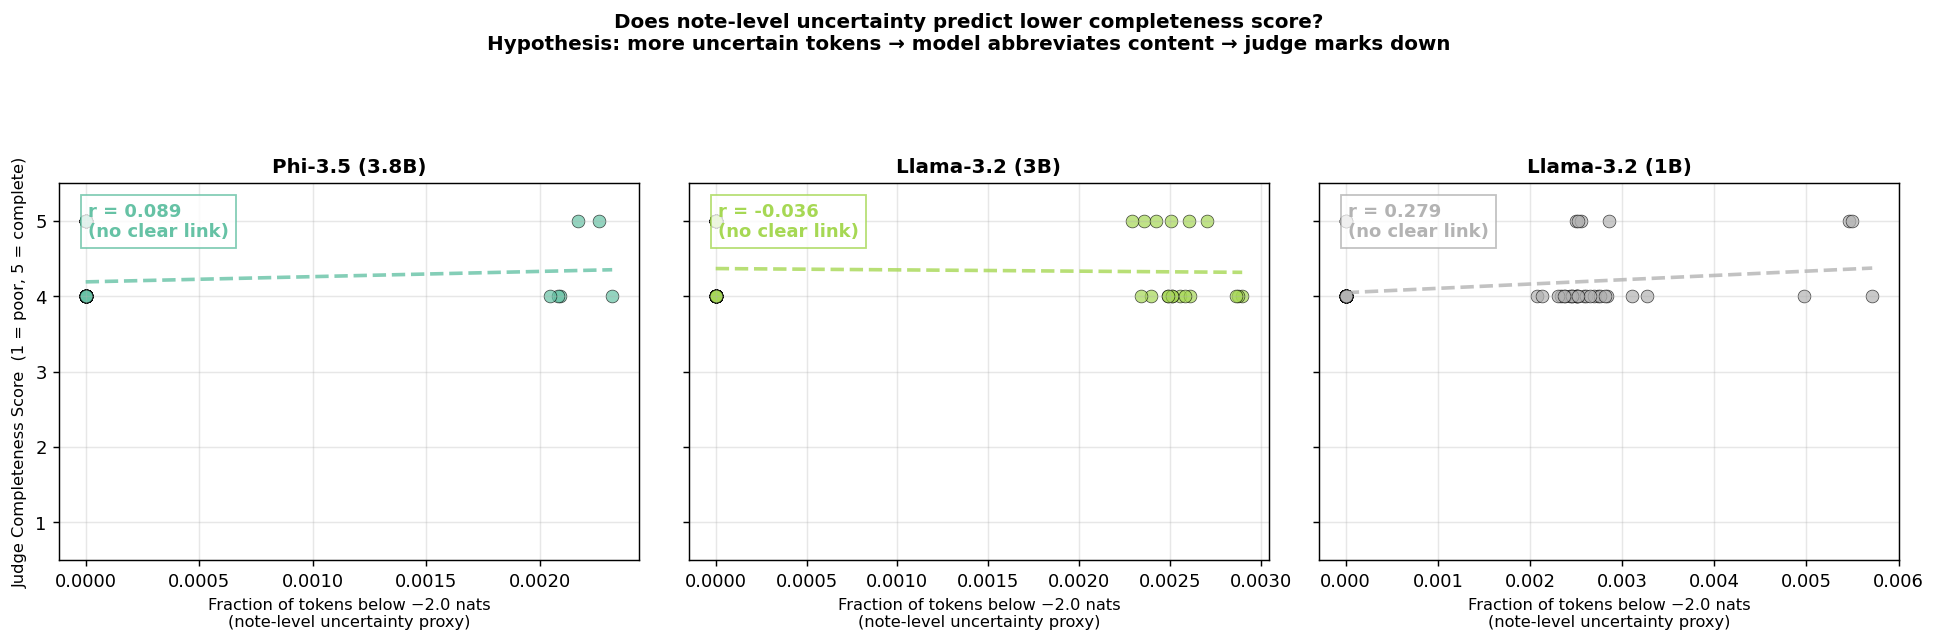


r < −0.3 → higher uncertainty predicts lower completeness (hypothesis supported)
r ≈  0   → uncertainty and completeness are independent


In [229]:

# ── 8.6: Does per-note uncertainty predict lower completeness? ──────────────────
# If the model was uncertain about what to write, it might write less — which
# would come out as a lower completeness score from the judge.
#
# I correlate frac_low_conf (note-level uncertainty proxy) with judge_completeness.
#   r < −0.2 → more uncertainty → lower completeness (hypothesis supported)
#   r ≈  0   → uncertainty and completeness are independent
#
# Note: judge_completeness is only available after re-running the §3 compute cell.

fig, axes = plt.subplots(1, len(LABELS), figsize=(15, 5), sharey=True)
fig.suptitle(
    "Does note-level uncertainty predict lower completeness score?\n"
    "Hypothesis: more uncertain tokens → model abbreviates content → judge marks down",
    fontsize=11, fontweight="bold"
)

print("Pearson r(frac_low_conf, judge_completeness):\n")

for i, label in enumerate(LABELS):
    ax    = axes[i]
    stats = all_results[label]["sample_stats"]

    if not any("judge_completeness" in s for s in stats):
        ax.text(0.5, 0.5,
                "Re-run the §3 compute cell\nto populate judge_completeness",
                transform=ax.transAxes, ha="center", va="center", fontsize=10,
                color="red", style="italic")
        ax.set_title(label, fontweight="bold")
        continue

    frac_lc = [s["frac_low_conf"]      for s in stats if "judge_completeness" in s]
    comp_sc = [s["judge_completeness"]  for s in stats if "judge_completeness" in s]

    ax.scatter(frac_lc, comp_sc, color=COLORS[i], alpha=0.7, s=50,
               edgecolors="black", linewidth=0.4)

    if len(set(comp_sc)) > 1 and len(frac_lc) > 2:
        z  = np.polyfit(frac_lc, comp_sc, 1)
        xs = np.linspace(min(frac_lc), max(frac_lc), 100)
        ax.plot(xs, np.poly1d(z)(xs), "--", color=COLORS[i], alpha=0.8, linewidth=2)
        r = np.corrcoef(frac_lc, comp_sc)[0, 1]
        interp = "uncertain ≈ incomplete" if r < -0.2 else "no clear link"
        ax.text(0.05, 0.95, f"r = {r:.3f}\n({interp})",
                transform=ax.transAxes, fontsize=10, color=COLORS[i],
                fontweight="bold", va="top",
                bbox=dict(facecolor="white", alpha=0.8, edgecolor=COLORS[i], linewidth=1))
        print(f"  {label}: r = {r:.4f}")
    else:
        print(f"  {label}: not enough variance to compute correlation")

    ax.set_xlabel("Fraction of tokens below −2.0 nats\n(note-level uncertainty proxy)", fontsize=9)
    if i == 0:
        ax.set_ylabel("Judge Completeness Score  (1 = poor, 5 = complete)", fontsize=9)
    ax.set_title(label, fontweight="bold", fontsize=11)
    ax.set_ylim(0.5, 5.5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.grid(alpha=0.3)

plt.subplots_adjust(top=0.82)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig(OUTPUT_DIR / "completeness_vs_uncertainty.png", dpi=150, bbox_inches="tight")
plt.show()
print()
print("r < −0.3 → higher uncertainty predicts lower completeness (hypothesis supported)")
print("r ≈  0   → uncertainty and completeness are independent")


  CRITICAL ERROR ANALYSIS — what errors did the judge flag?

────────────────────────────────────────────────────────────
  Phi-3.5 (3.8B)
────────────────────────────────────────────────────────────
  Samples with critical errors : 3/100
  Total individual errors logged: 3

  Error details:

    [1] Sample 5
         Error : Incorrectly identifies patient as a 79-year-old female instead of a 93-year-old male.
         Mean logprob  : -0.0277
         Hallucination score: 2

    [2] Sample 23
         Error : Prednisolone dosage is incorrect (30mg instead of 40mg)
         Mean logprob  : -0.0255
         Hallucination score: 4

    [3] Sample 59
         Error : Incorrect age and gender of the patient (69-year-old female instead of 85-year-old male). Aspirin dosage is incorrect (75mg instead of 300mg).
         Mean logprob  : -0.0395
         Hallucination score: 2

  Confidence comparison:
    Mean logprob on ERROR samples   : -0.0309  (n=3)
    Mean logprob on CORRECT samples : -0.

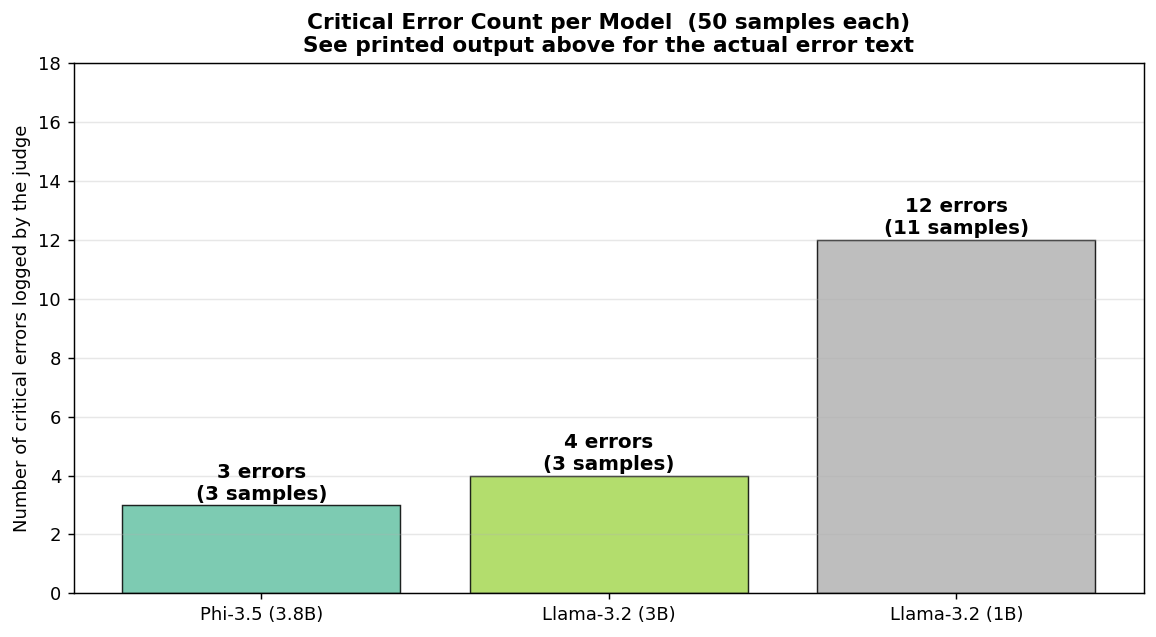

In [230]:

# ── 8.7: What were the actual critical errors? ─────────────────────────────────
# Until now I've just flagged has_critical_errors = True/False.
# The judge wrote out the actual error descriptions as text strings (critical_errors list).
# I print every error and check if the model's logprob confidence was lower on
# those samples vs the ones with no errors.
#
# With only ~5–15 errors total per model, this is qualitative — but reading them
# tells me exactly what clinical mistakes are being made (wrong medication doses,
# missing diagnoses, wrong attribution, etc.).
#
# Note: the critical_errors field is only populated after re-running the §3 compute cell.

print("=" * 65)
print("  CRITICAL ERROR ANALYSIS — what errors did the judge flag?")
print("=" * 65)

error_summary = {label: {"errors": [], "error_confs": [], "ok_confs": []} for label in LABELS}

for label in LABELS:
    stats = all_results[label]["sample_stats"]
    print(f"\n{'─'*60}")
    print(f"  {label}")
    print(f"{'─'*60}")

    for s in stats:
        errors = s.get("critical_errors", [])
        if errors:
            for err in errors:
                error_summary[label]["errors"].append({
                    "text":               err,
                    "sample_idx":         s["sample_idx"],
                    "mean_logprob":       s["mean_logprob"],
                    "judge_hallucination": s["judge_hallucination"],
                })
            error_summary[label]["error_confs"].append(s["mean_logprob"])
        else:
            error_summary[label]["ok_confs"].append(s["mean_logprob"])

    all_e     = error_summary[label]["errors"]
    n_sam_err = sum(1 for s in stats if s.get("has_critical_errors", False))
    print(f"  Samples with critical errors : {n_sam_err}/{len(stats)}")
    print(f"  Total individual errors logged: {len(all_e)}")

    if all_e:
        print(f"\n  Error details:")
        for j, e in enumerate(all_e):
            print(f"\n    [{j+1}] Sample {e['sample_idx']}")
            print(f"         Error : {e['text']}")
            print(f"         Mean logprob  : {e['mean_logprob']:.4f}")
            print(f"         Hallucination score: {e['judge_hallucination']}")

        ec = error_summary[label]["error_confs"]
        nc = error_summary[label]["ok_confs"]
        if ec and nc:
            diff = np.mean(ec) - np.mean(nc)
            direction = (
                "MORE uncertain on error samples ← uncertainty is a signal" if diff < -0.002
                else "LESS uncertain — model was confidently wrong"
                if diff > 0.002 else "about the same confidence on both"
            )
            print(f"\n  Confidence comparison:")
            print(f"    Mean logprob on ERROR samples   : {np.mean(ec):.4f}  (n={len(ec)})")
            print(f"    Mean logprob on CORRECT samples : {np.mean(nc):.4f}  (n={len(nc)})")
            print(f"    Difference {diff:+.4f} → model was {direction}")
    else:
        print("  (No critical_errors stored — re-run §3 compute cell to populate this field)")

# Bar chart — error counts per model
fig, ax = plt.subplots(figsize=(9, 5))
bar_heights = [len(error_summary[label]["errors"]) for label in LABELS]
bar_samples = [
    sum(1 for s in all_results[label]["sample_stats"] if s.get("has_critical_errors", False))
    for label in LABELS
]

for i, (label, nh, ns) in enumerate(zip(LABELS, bar_heights, bar_samples)):
    ax.bar(i, nh, color=COLORS[i], edgecolor="black", linewidth=0.8, alpha=0.85)
    ax.text(i, nh + 0.05, f"{nh} errors\n({ns} samples)",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, fontsize=10)
ax.set_ylabel("Number of critical errors logged by the judge", fontsize=10)
ax.set_ylim(0, max(max(bar_heights) * 1.5, 3))
ax.set_title("Critical Error Count per Model  (50 samples each)\n"
             "See printed output above for the actual error text",
             fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "critical_errors_count.png", dpi=150, bbox_inches="tight")
plt.show()



## 9 · Comprehensive Uncertainty Metrics Table

A single reference table in the style of Table A / Table C from the dissertation, combining
per-section and overall uncertainty metrics for all three models.

**Columns (overall rows):** Mean LogProb, Perplexity, Frac < −2 nats, AUROC (LN-NLL), AUROC (Seq-NLL), ECE, r(lp, halluc), r(lp, overall)

**Section rows** show only the confidence-level metrics (Mean LogProb, Perplexity, Frac < −2 nats) because the LLM judge provides *sample-level* quality scores, not per-section labels, so AUROC / ECE / r cannot be computed per section.

References: Kadavath et al. (2022); Kuhn et al. (2023) §3.3, §6; Xiong et al. (2024) §4, Table 5; Guo et al. (2017).


In [231]:

# ── §9: Comprehensive Uncertainty Metrics Table ────────────────────────────────
import pandas as pd
from IPython.display import display

# Column definitions:
#   Mean LogProb ↑    mean token logprob (Kadavath 2022; Xiong 2024 len-norm-prob)
#   Std LogProb       cross-sample std of mean_logprob across 50 encounters
#   Perplexity ↓      exp(−mean_logprob); lower = more confident (Kuhn 2023 §3.3)
#   Frac < −2 nats ↓  fraction of tokens with logprob < −2.0 (below 13.5% prob)
#   AUROC (LN-NLL) ↑  ROC-AUC using neg length-norm NLL; random = 0.5
#   AUROC (Seq-NLL) ↑ ROC-AUC using raw sequence NLL (biased to longer outputs)
#   ECE ↓             Expected Calibration Error (Guo 2017; Xiong 2024 §3.2)
#   r(lp, halluc)     Pearson r(mean_logprob, judge_hallucination 1–5)
#   r(lp, overall)    Pearson r(mean_logprob, judge_overall 1–5)

METRIC_COLS = [
    "Mean LogProb ↑", "Std LogProb",
    "Perplexity ↓", "Frac < −2 nats ↓",
    "AUROC (LN-NLL) ↑", "AUROC (Seq-NLL) ↑",
    "ECE ↓", "r(lp, halluc)", "r(lp, overall)",
]

# ── 1. Build row data ──────────────────────────────────────────────────────────
rows, overall_idx = [], []

for label in LABELS:
    d          = all_results[label]
    stats_list = d["sample_stats"]
    sec_sum    = d["section_summary"]
    auroc_d    = d["auroc"]
    ece_d      = d["ece"]
    corr       = d["correlation"]

    mlps  = [s["mean_logprob"]  for s in stats_list]
    perps = [s["perplexity"]    for s in stats_list]
    flcf  = [s["frac_low_conf"] for s in stats_list]

    overall_idx.append(len(rows))
    rows.append({
        "Model": label, "Scope": "Overall",
        "Mean LogProb ↑":     float(np.mean(mlps)),
        "Std LogProb":        float(np.std(mlps)),
        "Perplexity ↓":       float(np.mean(perps)),
        "Frac < −2 nats ↓":  float(np.mean(flcf)),
        "AUROC (LN-NLL) ↑":  auroc_d["length_norm_nll"],
        "AUROC (Seq-NLL) ↑": auroc_d["sequence_nll"],
        "ECE ↓":              ece_d["ece"],
        "r(lp, halluc)":     corr["logprob_vs_hallucination"],
        "r(lp, overall)":    corr["logprob_vs_overall"],
    })

    for sec_key, sec_display in CLINICAL_SECTIONS:
        sv = sec_sum.get(sec_key)
        if sv is None:
            continue
        n_s = sv.get("num_samples", 0)
        rows.append({
            "Model": "", "Scope": f"  └ {sec_display} (n={n_s})",
            "Mean LogProb ↑":     sv.get("mean_logprob",      float("nan")),
            "Std LogProb":        sv.get("std_logprob",        float("nan")),
            "Perplexity ↓":       sv.get("mean_perplexity",   float("nan")),
            "Frac < −2 nats ↓":  sv.get("mean_frac_low_conf", float("nan")),
            "AUROC (LN-NLL) ↑":  float("nan"),
            "AUROC (Seq-NLL) ↑": float("nan"),
            "ECE ↓":              float("nan"),
            "r(lp, halluc)":     float("nan"),
            "r(lp, overall)":    float("nan"),
        })

df_uq = pd.DataFrame(rows)
sec_idx = [i for i in range(len(df_uq)) if i not in overall_idx]

# ── 2. Theme-safe styling ──────────────────────────────────────────────────────
# Rules:
#   1) All cells: white background + black text (explicit, not theme-inherited)
#   2) Gradient cells: always paired with color: #000000 (prevents invisible text
#      if VS Code renders output on a dark background)
#   3) Overall rows: light steel-blue band with explicit black text + bold
#   4) Section rows: white bg, smaller font — no hardcoded text color

def _row_style(row):
    scope = df_uq.at[row.name, "Scope"]
    if scope == "Overall":
        # Light blue band — readable on both light and dark VS Code themes
        # because the background + text colors are both explicit
        return [
            "background-color: #dce8f5; color: #000000; font-weight: bold; "
            "border-top: 2px solid #5b9bd5; border-bottom: 1px solid #aac8ea;"
        ] * len(row)
    # Section rows: explicit white bg + black text, smaller font
    return [
        "background-color: #fafafa; color: #000000; font-size: 0.86em;"
    ] * len(row)

# Define gradient subsets
_auroc_cols  = ["AUROC (LN-NLL) ↑", "AUROC (Seq-NLL) ↑"]
_ece_cols    = ["ECE ↓"]
_lp_cols     = ["Mean LogProb ↑"]
_perp_cols   = ["Perplexity ↓"]
_r_cols      = ["r(lp, halluc)", "r(lp, overall)"]
_sec_conf    = ["Mean LogProb ↑", "Perplexity ↓", "Frac < −2 nats ↓"]

styler = (
    df_uq.style
    .format({c: "{:.4f}" for c in METRIC_COLS}, na_rep="—")
    # ── Row highlight (applied first — gradient will override metric bg for overall rows,
    #    which is fine: gradient cells get new bg but row style's text is set per-cell
    #    after via the .map() calls below) ─────────────────────────────────────
    .apply(_row_style, axis=1)
    # ── Metric gradients (overall rows only) ──────────────────────────────────
    .background_gradient(
        cmap="RdYlGn", vmin=0.25, vmax=0.75,
        subset=pd.IndexSlice[overall_idx, _auroc_cols],
    )
    .background_gradient(
        cmap="RdYlGn_r", vmin=0.10, vmax=0.70,
        subset=pd.IndexSlice[overall_idx, _ece_cols],
    )
    .background_gradient(
        cmap="RdYlGn",
        subset=pd.IndexSlice[overall_idx, _lp_cols],
    )
    .background_gradient(
        cmap="RdYlGn_r",
        subset=pd.IndexSlice[overall_idx, _perp_cols],
    )
    .background_gradient(
        cmap="RdYlGn", vmin=-0.4, vmax=0.4,
        subset=pd.IndexSlice[overall_idx, _r_cols],
    )
    # ── Per-section gradient ───────────────────────────────────────────────────
    .background_gradient(
        cmap="RdYlGn", axis=0,
        subset=pd.IndexSlice[sec_idx, _sec_conf],
    )
    # ── CRITICAL: force black text on ALL gradient-colored cells ──────────────
    # background_gradient only sets background-color, not color. On dark VS Code
    # themes the inherited text color may be light, making values invisible.
    # Explicit color: #000000 here guarantees readability regardless of theme.
    .map(lambda _: "color: #000000;",
         subset=pd.IndexSlice[overall_idx,
                               _auroc_cols + _ece_cols + _lp_cols + _perp_cols + _r_cols])
    .map(lambda _: "color: #000000;",
         subset=pd.IndexSlice[sec_idx, _sec_conf])
    # ── Caption & table structure ──────────────────────────────────────────────
    .set_caption(
        "Table UQ — Uncertainty Quantification Metrics "
        "(ft_rag · 50 samples · ACI-Bench 2023)\n"
        "↑ higher is better  │  ↓ lower is better  │  "
        "— = not applicable (AUROC / ECE / r need sample-level judge labels, "
        "unavailable per section)"
    )
    .set_table_styles([
        {"selector": "caption",
         "props": ("caption-side: top; font-size: 1.02em; font-weight: bold; "
                   "text-align: left; padding: 4px 0 10px 0;")},
        {"selector": "thead th",
         "props": ("background-color: #3d3d3d; color: #ffffff; "
                   "font-size: 0.84em; text-align: center; "
                   "padding: 7px 10px; white-space: nowrap; "
                   "border-bottom: 2px solid #222222;")},
        {"selector": "td",
         "props": ("font-size: 0.87em; text-align: center; "
                   "padding: 4px 8px; border-bottom: 1px solid #e0e0e0;")},
        {"selector": "td:nth-child(1), td:nth-child(2)",
         "props": "text-align: left; white-space: nowrap;"},
        {"selector": "table",
         "props": "border-collapse: collapse; width: 100%;"},
    ])
    .hide(axis="index")
)

display(styler)

#  3. Sample prevalence mini-table 
prev_rows = []
for label in LABELS:
    a = all_results[label]["auroc"]
    n = a["n_correct"] + a["n_incorrect"]
    prev_rows.append({
        "Model":                label,
        "N Correct (halluc>3)": a["n_correct"],
        "N Hallucinated":       a["n_incorrect"],
        "N Total":              n,
        "% Hallucinated":       f"{a['n_incorrect']/n:.1%}",
    })

df_prev = pd.DataFrame(prev_rows)



def _halluc_rate(val):
    """Light background scale: low rate green, high rate red. Always black text."""
    try:
        pct = float(val.rstrip("%")) / 100
    except (AttributeError, ValueError):
        return ""
    if pct < 0.30:
        bg = "#c8e6c9"
    elif pct < 0.55:
        bg = "#fff9c4"
    else:
        bg = "#ffcdd2"
    return f"background-color: {bg}; color: #000000;"

prev_styler = (
    df_prev.style
    .set_caption("Sample Prevalence — AUROC context "
                 "(hallucination rate = judge_hallucination ≤ 3 / N total)")
    .map(_halluc_rate, subset=["% Hallucinated"])
    .map(lambda _: "color: #000000;", subset=["N Hallucinated"])
    .background_gradient(cmap="Reds", subset=["N Hallucinated"])
    .map(lambda _: "color: #000000;", subset=["N Hallucinated"])
    .set_table_styles([
        {"selector": "caption",
         "props": ("caption-side: top; font-size: 0.94em; font-weight: bold; "
                   "text-align: left; padding: 14px 0 6px 0;")},
        {"selector": "thead th",
         "props": ("background-color: #3d3d3d; color: #ffffff; "
                   "font-size: 0.84em; text-align: center; padding: 6px 12px;")},
        {"selector": "td",
         "props": ("background-color: #ffffff; color: #000000; "
                   "font-size: 0.87em; text-align: center; padding: 4px 12px;")},
        {"selector": "td:nth-child(1)",
         "props": "text-align: left; white-space: nowrap; font-weight: bold;"},
        {"selector": "table", "props": "border-collapse: collapse;"},
    ])
    .hide(axis="index")
)
display(prev_styler)

#  4. Save .md 
def _fmt_md(v, dec=4):
    try:
        f = float(v)
        return "—" if np.isnan(f) else f"{f:.{dec}f}"
    except (TypeError, ValueError):
        return "—"

md_header = (
    "| Model | Scope "
    "| Mean LogProb ↑ | Std LogProb | Perplexity ↓ | Frac < −2 nats ↓ "
    "| AUROC (LN-NLL) ↑ | AUROC (Seq-NLL) ↑ | ECE ↓ "
    "| r(lp, halluc) | r(lp, overall) |"
)
md_sep = "|---|---|---|---|---|---|---|---|---|---|---|"
md_rows = [md_header, md_sep]

for i_m, label in enumerate(LABELS):
    d          = all_results[label]
    stats_list = d["sample_stats"]
    sec_sum    = d["section_summary"]
    auroc_d    = d["auroc"]
    ece_d      = d["ece"]
    corr       = d["correlation"]

    mlps  = [s["mean_logprob"]  for s in stats_list]
    perps = [s["perplexity"]    for s in stats_list]
    flcf  = [s["frac_low_conf"] for s in stats_list]

    if i_m > 0:
        md_rows.append(md_sep)
    md_rows.append(
        f"| {label} | **Overall** "
        f"| {np.mean(mlps):.4f} | {np.std(mlps):.4f} | {np.mean(perps):.4f} | {np.mean(flcf):.4f} "
        f"| {auroc_d['length_norm_nll']:.4f} | {auroc_d['sequence_nll']:.4f} "
        f"| {ece_d['ece']:.4f} "
        f"| {corr['logprob_vs_hallucination']:.4f} | {corr['logprob_vs_overall']:.4f} |"
    )
    for sec_key, sec_display in CLINICAL_SECTIONS:
        sv = sec_sum.get(sec_key)
        if sv is None:
            continue
        n_s = sv.get("num_samples", 0)
        md_rows.append(
            f"|  | {sec_display} (n={n_s}) "
            f"| {_fmt_md(sv.get('mean_logprob'))} "
            f"| {_fmt_md(sv.get('std_logprob'))} "
            f"| {_fmt_md(sv.get('mean_perplexity'))} "
            f"| {_fmt_md(sv.get('mean_frac_low_conf'))} "
            f"| — | — | — | — | — |"
        )

md_rows.append(md_sep)



md_content = "\n".join([
    "# Table UQ: Uncertainty Quantification Metrics",
    "",
    "Config: `ft_rag` (fine-tuned + Dense+Rerank RAG).  "
    "50-sample ACI-Bench 2023 test set.",
    "AUROC binarisation: `judge_hallucination > 3` = correct "
    "(Kuhn et al. 2023; Xiong et al. 2024 Table 5).",
    "ECE: token confidence = `exp(mean_logprob)` vs binary output correctness "
    "(Guo et al. 2017; Xiong et al. 2024 §3.2).",
    "↑ = higher is better; ↓ = lower is better.",
    "AUROC, ECE and r: overall-level only — per-section judge labels unavailable.",
    "",
] + md_rows + [
    "",
    "## Sample Prevalence (AUROC context)",
    "",
    "| Model | N Correct (halluc > 3) | N Hallucinated | N Total | % Hallucinated |",
    "|---|---|---|---|---|",
] + [
    f"| {label} | {all_results[label]['auroc']['n_correct']} "
    f"| {all_results[label]['auroc']['n_incorrect']} "
    f"| {all_results[label]['auroc']['n_correct'] + all_results[label]['auroc']['n_incorrect']} "
    f"| {all_results[label]['auroc']['n_incorrect'] / (all_results[label]['auroc']['n_correct'] + all_results[label]['auroc']['n_incorrect']):.1%} |"
    for label in LABELS
] + [
    "",
    "## Column Definitions",
    "",
    "| Column | Definition | Reference |",
    "|---|---|---|",
    "| Mean LogProb ↑ | Mean token log-prob; higher (less negative) = more confident | Kadavath et al. (2022); Xiong et al. (2024) |",
    "| Std LogProb | Cross-sample std of mean_logprob; variability of confidence across encounters | — |",
    "| Perplexity ↓ | exp(−mean_logprob); lower = more confident | Kuhn et al. (2023) §3.3 |",
    "| Frac < −2 nats ↓ | Fraction of tokens with logprob < −2.0 (below 13.5% prob) | Xiong et al. (2024) |",
    "| AUROC (LN-NLL) ↑ | AUROC with length-norm NLL as uncertainty score; random = 0.5 | Kuhn et al. (2023) §6; Xiong et al. (2024) Table 5 |",
    "| AUROC (Seq-NLL) ↑ | AUROC with raw sequence NLL; biased toward longer outputs | Kuhn et al. (2023) |",
    "| ECE ↓ | Expected Calibration Error; token confidence vs output correctness gap | Guo et al. (2017) |",
    "| r(lp, halluc) | Pearson r(mean_logprob, judge_hallucination 1–5); overall only | — |",
    "| r(lp, overall) | Pearson r(mean_logprob, judge_overall 1–5); overall only | — |",
])



out_path = OUTPUT_DIR / "table_uq_uncertainty.md"
out_path.write_text(md_content, encoding="utf-8")
print(f"Markdown saved → {out_path}")


Model,Scope,Mean LogProb ↑,Std LogProb,Perplexity ↓,Frac < −2 nats ↓,AUROC (LN-NLL) ↑,AUROC (Seq-NLL) ↑,ECE ↓,"r(lp, halluc)","r(lp, overall)"
Phi-3.5 (3.8B),Overall,-0.0280,0.0066,1.0284,0.0001,0.5320,0.5460,0.2824,0.1478,0.1637
,└ Chief Complaint (n=100),-0.0163,0.0227,1.0164,0.0000,—,—,—,—,—
,└ HPI (n=100),-0.0504,0.0203,1.0516,0.0007,—,—,—,—,—
,└ Past Medical Hx (n=100),-0.0072,0.0233,1.0072,0.0000,—,—,—,—,—
,└ Medications (n=100),-0.0047,0.0149,1.0047,0.0000,—,—,—,—,—
,└ Allergies (n=100),-0.0189,0.0136,1.0191,0.0000,—,—,—,—,—
,└ Examination (n=100),-0.0189,0.0174,1.0190,0.0000,—,—,—,—,—
,└ Assessment (n=100),-0.0307,0.0269,1.0312,0.0000,—,—,—,—,—
,└ Plan (n=100),-0.0365,0.0254,1.0371,0.0000,—,—,—,—,—
,└ Safety Netting (n=100),-0.0232,0.0112,1.0235,0.0000,—,—,—,—,—


Model,N Correct (halluc>3),N Hallucinated,N Total,% Hallucinated
Phi-3.5 (3.8B),69,31,100,31.0%
Llama-3.2 (3B),65,35,100,35.0%
Llama-3.2 (1B),32,68,100,68.0%


Markdown saved → d:\ambient-scribe\notebooks\logprobs_analysis_output\table_uq_uncertainty.md
